#**An Introduction to Quantum Error Correction**
*by Kanishka Padamata, Knowledge associate at C-DAC Pune*

- Quantum computers promise **Quantum Advantage** that is exponential speedups for problems in chemistry, cryptography, optimization, and more.

- But **Quantum Information is notoriously fragile :** Qubits are susceptible to decoherence, gate errors, measurement noise, and crosstalk.

- To Build a Reliable Quantum computer we need a protection against these errors: **Quantum Error Correction(QEC)**





# **Qiskit Installation**

Before we start working with quantum circuits, we need to install **Qiskit** and some additional libraries.


Qiskit is an open-source Python framework developed by IBM for working with quantum computers. It allows us to:

✔ Design and simulate quantum circuits  
✔ Run experiments on real IBM Quantum devices  
✔ Visualize results using different plotting tools  

**The following command installs the latest version of Qiskit, including its core components which includes:**

- `qiskit` → Core Qiskit library (Quantum circuits, gates, transpilers)
- `qiskit-aer` → Required for simulating quantum circuits on classical hardware

In [3]:
!pip install qiskit
!pip install qiskit-aer

Defaulting to user installation because normal site-packages is not writeable
Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com



[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: C:\Users\vmuno\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com



[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: C:\Users\vmuno\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [6]:
# Diagnostic: Check which Python environment the kernel is using
import sys
import subprocess

print("Python executable:", sys.executable)
print("Python version:", sys.version)
print("\nInstalling qiskit in the kernel's Python environment...")
print("=" * 60)

# Install qiskit using the kernel's Python to ensure it's in the right environment
# This ensures qiskit is installed in the same Python that the kernel is using
subprocess.check_call([sys.executable, "-m", "pip", "install", "qiskit", "qiskit-aer"])


Python executable: C:\Users\vmuno\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe
Python version: 3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]

Installing qiskit in the kernel's Python environment...


0

In [7]:
#check version of qiskit
import qiskit
print(qiskit.__version__)  # Should print the installed version

2.2.3


## **Installing Additional Libraries**  
Qiskit uses **Matplotlib** for visualizing quantum circuits and Bloch spheres.

For example, the **pylatexenc** library is needed for Matplotlib-based circuit diagrams.

In [10]:
# Diagnostic: Check which Python environment the kernel is using
import sys
import subprocess

print("Python executable:", sys.executable)
print("Python version:", sys.version)
print("\nInstalling qiskit in the kernel's Python environment...")
print("=" * 60)

# Install qiskit using the kernel's Python to ensure it's in the right environment
# This ensures qiskit is installed in the same Python that the kernel is using
subprocess.check_call([sys.executable, "-m", "pip", "install", "matplotlib", "pylatexenc"])


Python executable: C:\Users\vmuno\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe
Python version: 3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]

Installing qiskit in the kernel's Python environment...


0

In [8]:
!pip install matplotlib
!pip install pylatexenc

Defaulting to user installation because normal site-packages is not writeable
Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.1 MB 1.2 MB/s eta 0:00:07
   --- ------------------------------------ 0.8/8.1 MB 1.2 MB/s eta 0:00:07
   ----- ---------------------------------- 1.0/8.1 MB 1.2 MB/s eta 0:00:06
   ------ --------------------------------- 1.3/8.1 MB 1.2 MB/s eta 0:00:06
   ------- -------------------------------- 1.6/8.1 MB 1.2 MB/s eta 0:00:06
   --------- ------------------------------ 1.8/8.1 MB 1.2 MB/s eta 0:00:06
   ---------- ----------------------------- 2.1/8.1 MB 1.2 MB/s eta 0:00:06
   ----------- ---------------------------- 2.4/8.1 MB 1.2 MB/s eta 0:00:05
   ------------ ------------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: C:\Users\vmuno\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136928 sha256=8e102672054ad8e8fa30d935ed56d7f41c9d81ff5f3268cdd459cd8c44c132de
  Stored in directory: C:\Users\vmuno\AppData\Local\Temp\pip-ephem-wheel-cache-jomd48lf\wheels\06\3e\78\fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: C:\Users\vmuno\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


## **Import Libraries**

In [11]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, AncillaRegister, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from qiskit.quantum_info import Statevector

from IPython.display import display, Latex

import numpy as np
import matplotlib.pyplot as plt
import pylatexenc

## **Run a sample circuit**

The process of generating a quantum circuit in Qiskit involves the following steps:


1. **Create a quantum circuit**  
   - Define quantum and classical registers  
2. **Apply gate operations and measurements**  
   - Manipulate qubits using quantum gates  
   - Measure qubits to extract classical outcomes  
3. **Initialize a simulator**  
   - Use a quantum simulator to execute the circuit
   - This runs quantum operations on classical hardware
4. **Run the circuit on the simulator and retrieve results**  
   - Execute the circuit and analyze the output

\\
Let's Run a Small 2-Qubit Circuit

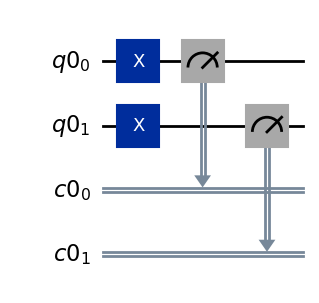

In [12]:
'''Step 1: Create a quantum circuit'''

qr = QuantumRegister(2) # Initialize Quantum Register that can store 2 qubits
cr = ClassicalRegister(2) # Initialize classical Register that can store 2 classical bits
qc = QuantumCircuit(qr, cr)     # create a circuit from these registers

'''Step 2: Apply Gate operations and measurements'''

#apply X gate on qubit 0
qc.x(qr[0])


#apply X on qubit 1
qc.x(qr[1])


#measure the qubits
qc.measure(qr,cr)
qc.draw(output='mpl', cregbundle=False)

# or you can write the below which will also give same output
# qc.draw('mpl')

{'11': 1024}


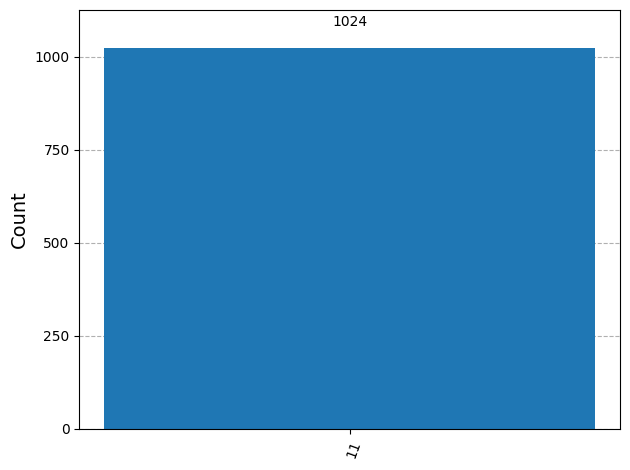

In [13]:
'''Step 3: Initialize a simulator'''

#Intialize the simulator
backend = AerSimulator()   #This is general purpose quantum simulator framework but qiskit does have other specialized simulators



'''Step 4: Run the circuit on the simulator and retrieve results'''

# Create the circuit for the give
# Run ideal simulation

job = backend.run(qc, shots=1024)

# Get results
result = job.result()
counts = result.get_counts()



# Step 5: Print and plot the output
print(counts)
plot_histogram(counts)

# ideal_results = backend.run(transpile(qc, backend), shots=1000).result()
# ideal_counts = ideal_results.get_counts()

# **1. Classical Error Correcting codes**
This section is a primer on some classical coding theory notations and 3-bit repitition code


## **1.1 Classical 3-bit Repitition Code**

 >_**Example:** If asked a yes-or-no question, answering “yes, yes, yes” is clear and ensures accuracy, even if one "yes" turns to "no."_

-  The **Redundancy allows correction.**

> _In **classical error correction**, The 3-bit repetition code encodes information in three bits.` If one bit flips due to noise, the
other two will still provide the correct answer`._

**Process:**

| Step           | Action                                         | Example              |
| -------------- | ---------------------------------------------- | -------------------- |
| **1. Encode**  | Repeat the bit three times                     | 0 → `000`, 1 → `111` |
| **2. Error**   | Noise may flip a bit                           | `111` → `101`        |
| **3. Decode**  | Use **majority vote** to decide original value | 2 ones → decode as 1 |
| **4. Correct** | Replace noisy word with clean codeword         | `101` → `111`        |







In [14]:
def majority_vote(bits):

    #Performs a majority vote on a n-bit string.
    #Returns the decoded logical bit (0 or 1).

    return int(bits.count('1') > 1)

print("Classical Repetition Code Example:")
print("Input: 001 -> Decoded:", majority_vote("001"))
print("Input: 010 -> Decoded:", majority_vote("010"))
print("Input: 100 -> Decoded:", majority_vote("100"))


# What if two bits are flipped?
print("\nWhat if Two Bits are Flipped ? Our intial state 000 > 110")
print("Input: 110 -> Decoded:", majority_vote("110"))

Classical Repetition Code Example:
Input: 001 -> Decoded: 0
Input: 010 -> Decoded: 0
Input: 100 -> Decoded: 0

What if Two Bits are Flipped ? Our intial state 000 > 110
Input: 110 -> Decoded: 1


> The 3-bit repetition code **can correct 1 bit-flip** and **detect up to 2 errors**.


We saw that:
- If **1 bit** is flipped, the majority vote decodes correctly.
- If **2 bits** flip, majority vote fails — we get the wrong decoded bit.
- So it seems the code is:
    - **able** to **correct 1 error**
    - **unable** to correct 2 errors (though it still **detects** them)

### Why is this happening?

To understand that, we need to talk about something called the **Hamming Distance**.


## 1.2 What is Hamming Distance?

The **Hamming distance** between two strings is the number of bit positions in which they differ.

### Example:
- Distance between `000` and `111` = 3 (all bits differ)
- Distance between `000` and `001` = 1 (only last bit differs)



## 1.3 Codewords and Codespace

In the 3-bit repetition code:
- We **only allow** `000` and `111` as valid encoded states.
- These are called the **codewords**.
- The space of all valid encodings is called the **codespace**.

> Any string that's not a codeword (like 010 or 101) is assumed to have **errors**.



## 1.4 What Does "Distance 3" Mean?

- The **minimum distance between any two codewords** is **3** (from `000` to `111`).
- That's why this is called a **distance-3 code**.



## 1.5  $[n, k, d]$ Notation

Now we can define the parameters of a code:

### Parameters of the 3-Bit Repetition Code

### 3-Bit Repetition Code Parameters

```
┌─────────┬─────────────────────────────────────────────┬───────────────────────────────┐
│ Symbol  │ Meaning                                     │ Value                         │
├─────────┼─────────────────────────────────────────────┼───────────────────────────────┤
│ n       │ Number of physical bits used                │ 3                             │
│ k       │ Number of logical bits encoded              │ 1                             │
│ d       │ Minimum Hamming distance between codewords  │ 3                             │
└─────────┴─────────────────────────────────────────────┴───────────────────────────────┘
```


> This is a **[3, 1, 3]** code:  
> It can **correct 1 bit-flip error** and **detect up to 2 errors**




## 1.6 Why Does Distance Matter?

- A code with distance **d**:
    - Can detect up to  $d - 1$ errors
    - Can correct up to $t = \left\lfloor \frac{d - 1}{2} \right\rfloor,$errors

So for our `[3,1,3]` code:
- Detects up to **2** errors
- Corrects up to **1** error

And that's exactly what we observed with majority voting!

## Summary

-  The [3,1,3] repetition code uses 3 physical bits to store 1 logical bit.

-  It has two codewords: 000 and 111.
-  The minimum distance is 3 (Hamming distance).
- Can correct 1 error and detect up to 2.


# **2. What are Quantum Errors**

Before we can correct quantum errors, we need to understand what kinds of errors quantum systems are susceptible to—and how they differ from classical noise.

Quantum errors fall into two broad categories:

## **2.1 Coherent Errors**
 - These are **systematic and unitary.**
 - Think of them as **unintended over- or under-rotations—like a slightly miscalibrated gate.**
 - While coherent errors may seem less threatening, they can build up in a correlated and dangerous way over time.


## **2.2 Incoherent Errors**
- These arise from **unwanted interactions between a qubit and its surrounding environment.**
- These are *stochastic* in nature—examples include spontaneous decay (amplitude damping), thermal noise, and dephasing.




# **3. Challenges Of Quantum Error Correction**
- In classical computing, error correction is straightforward: copy the data and use majority voting.

- 3- bit repitition code is simple method but we can't apply as it is in the Quantum world.

**Why??**

Quantum systems come with several unique challenges that classical bits do not

1. **No-Cloning Theorem:** It's impossible to create an exact copy of an unknown quantum state.
2. **Measurement Problem :** Quantum states collapse upon measurement, complicating error detection without disturbing the quantum state.
3. **Quantum States are Continuous :** Quantum states are not discrete like classical bit. That is we also have to deal with Phase Flip errors.



# **4. 3-Qubit Bit Flip Repitition Code**

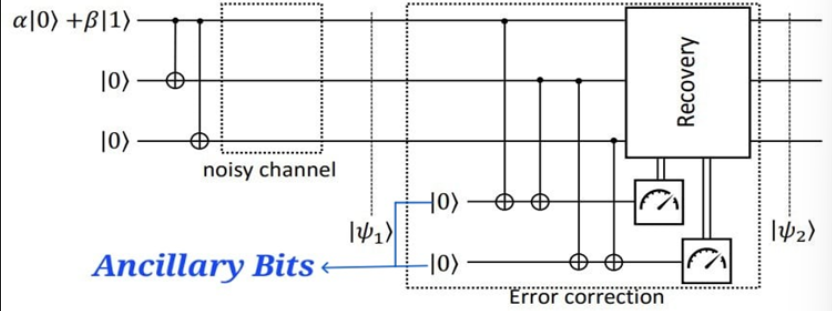

## **4.1 Encoding**

Instead of cloning **we use entanglement achieve redundancy** that is to encode the logical qubit into multiple physical qubits for repetition the computational basis states are:

      |0⟩ → |000⟩, |1⟩ → |111⟩ , α|0⟩ + β|1⟩ → α|000⟩ + β|111⟩




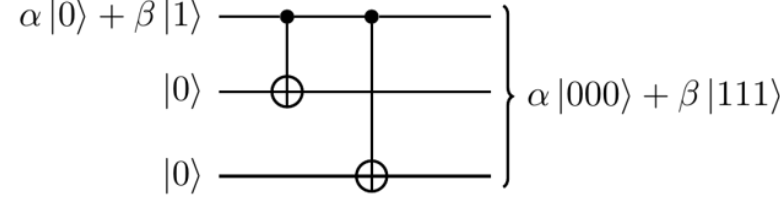

- This encoding is achieved using CNOT gates
- which spread the information across 3 qubits.

- **Logical Qubits:** These bits is the original quantum information we want to protect.
- **Physical Qubits:** The actual qubits used to redundantly encode the logical qubit.
- **Example:** The logical state $|0⟩$ is encoded as $|000⟩$ and $|1⟩$ as $|111⟩$.
In the encoded state $|000⟩$, each qubit is a physical qubit holding a piece of the logical information.

### **4.1.1  CNOT between $q_0=|ψ⟩$ as Control bit and $q_1=|0⟩$as target bit**


We start with the initial state with $|ψ⟩= q_0 = α|0⟩ + β|1⟩$ and $q_1=|0⟩
$

$$
CNOT = \begin{bmatrix}
1 & 0 & 0 & 0 \\
0 & 1 & 0 & 0 \\
0 & 0 & 0 & 1 \\
0 & 0 & 1 & 0
\end{bmatrix}_{4 \times 4}
$$



Expanding the action of CNOT using tensor notation:

$$
CNOT = (|0\rangle \langle 0| \otimes I  + |1\rangle \langle 1|\otimes  X )
$$
- If control bit **|0⟩** , apply identity **I** on the target.
- If control bit **|1⟩** , apply NOT gate **X** on the target.
- Applying CNOT on q₀ and q₁ **results in 2 qubit system**
$$
CNOT\cdot (\begin{bmatrix} \alpha \\ \beta \end{bmatrix} \otimes \begin{bmatrix} 1 \\ 0 \end{bmatrix}) =CNOT \cdot \begin{bmatrix} \alpha \\ 0 \\ \beta \\ 0 \end{bmatrix} = \begin{bmatrix} \alpha \\ 0 \\ 0 \\ \beta \end{bmatrix}
$$

- Thus state after first CNOT is an **entangled state of q₀ and q₁** :

$$
|q_{1}q_{0}\rangle = \alpha |00\rangle + \beta |11\rangle
$$



###   **4.1.2 CNOT on entangled state $|q_1 q_0⟩$ where q₀ is Control bit and $q_2=|0⟩$as target bit**



- This will create a **3-qubit System**
- Since CNOT is a 2 qubit gate we cannot apply this 4x4 matrix on this system
- we need to enlarge it for 3 qubits which will form a 8x8 matrix

The CNOT matrix is now an **8x8** matrix:
$$
CNOT_{8\times8} = (|0\rangle \langle 0| \otimes I \otimes I) + (1\rangle \langle 1|\otimes I \otimes X)
$$
- Applying CNOT on q₀ and q₁ and on q₁ we have to apply Identity since we are doing nothing on it

$$
CNOT\cdot (\begin{bmatrix} \alpha \\ 0 \\ 0 \\ \beta \end{bmatrix} \otimes \begin{bmatrix} 1 \\ 0 \end{bmatrix})= CNOT \cdot \begin{bmatrix} \alpha \\ 0 \\ 0 \\ 0 \\ 0 \\ 0 \\ \beta \\ 0 \end{bmatrix} = \begin{bmatrix} \alpha \\ 0 \\ 0 \\ 0 \\ 0 \\ 0 \\ 0\\ \beta \end{bmatrix}
$$


- This produces a 3-qubit entangled system **|q₂q₁q₀⟩**
$$
|q_{2}q_{1}q_{0}\rangle = \alpha|000\rangle + \beta |111\rangle
$$


**Examples**

1. If |ψ⟩ = |0⟩ , final state = |000⟩
2. If |ψ⟩ = |1⟩ , final state = |111⟩
3. If $$|\psi\rangle = \frac{1}{\sqrt{2}}(|0\rangle + |1\rangle)
   ,
    |\psi_{final}\rangle= \frac{1}{\sqrt{2}}(|000\rangle + |111\rangle)$$   , which is a **GHZ state** .

## **4.2 Induce an Error**


- This Encoded state goes through a noisy channel which will cause a single bit flip error on one of the bits

## **4.3 Syndrome Measurement and Decoding**



### **4.3.1 Syndrome Measurement:**


- In order to find where error has occured we need to check **parity (whether the two qubits it compares are the same or different)**
- This parity is checked by Two Ancillas(Extra Qubits To measure syndrome)
  - Ancilla 1 checks the parity b/w qubits 0(q₀) and 1(q₁).
  - Ancilla 2 checks the parity b/w qubits 1(q₁) and 2(q₂).
  - This is done by applying Cnots


- For Ancilla 1:
    
    1. **CNOT** applied on **q₀(control bit) and ancilla 1(target bit)**
    2. **CNOT** applied on **q₁(control bit) and ancilla 1(target bit)**
    3. Now when we **measure Ancilla 1** the answer is **XOR** of the **both the CNOTs**
    4. This Measurement in stored in Classical register for syndrome creg_syndrome[0]. (M1)
    
- For Ancilla 2:
    1. **CNOT** applied on **q₁(control bit) and ancilla 2(target bit)**
    2. **CNOT** applied on **q₂(control bit) and ancilla 2(target bit)**
    3. Now when we measure **Ancilla 1** the answer is **XOR** of the **both the CNOTs**
    4. This Measurement in stored in Classical register for syndrome creg_syndrome[1]. (M2)


### **4.3.2 Decoding**

       

- Decoding where error has occured based on the syndrome patterns
- So there exists Four Possible syndromes
   - `00`: NO ERROR
   - `01`: Error On Qubit 0 (q₀)
   - `11`: Error On Qubit 1 (q₁)
   - `10`: Error On Qubit 2 (q₂)
     


## **4.4 Error Correction**


- Apply Bit-Flip(X) on the bit where error has occur
- if you measure now you will get a corrected state

## Syndrome Table (look-up table)

$$
\begin{array}{|c|c|c|c|c|c|c|}
\hline
\textbf{Bit Flip Error} & |\psi_1\rangle & M_1 & M_2 & \text{Syndrome} & \text{Recovery} & \text{Final State} |\psi_f\rangle \\
\hline
\text{No Error} & \alpha |000\rangle + \beta |111\rangle & 0 & 0 & 00 & I \otimes I \otimes I & \alpha |000\rangle + \beta |111\rangle \\
\hline
q_0 \text{ Error} & \alpha |001\rangle + \beta |110\rangle & 1 & 0 & 01 & X \otimes I \otimes I & \alpha |000\rangle + \beta |111\rangle \\
\hline
q_1 \text{ Error} & \alpha |010\rangle + \beta |101\rangle & 1 & 1 & 11 & I \otimes X \otimes I & \alpha |000\rangle + \beta |111\rangle \\
\hline
q_2 \text{ Error} & \alpha |100\rangle + \beta |011\rangle & 0 & 1 & 10 & I \otimes I \otimes X & \alpha |000\rangle + \beta |111\rangle \\
\hline
\end{array}
$$

## **Coding The 3-bit Repitition code**

### **Initialize the circuit**

In [34]:
# Define quantum and classical registers
qreg = QuantumRegister(3, "q")  # Logical (data) qubits
areg = AncillaRegister(2, "ancilla")  # Explicitly defining ancilla qubits prevents unintended operations on ancilla qubits
creg_syndrome = ClassicalRegister(2, name="classical_syndrome")  # Stores syndrome measurement (c0, c1)
creg_logical = ClassicalRegister(1, name="classical_logical bit")  # Stores final logical qubit measurement

# Create the circuit
qc = QuantumCircuit(qreg,areg, creg_syndrome, creg_logical)


##if you want to provide custom state vector
#state =[0.6,0.8]
#custom_sv = Statevector(state)
#qc.initialize(custom_sv, qreg[0])  # Apply custom state

### **Encoding**

In [35]:
# Encoding: Spread logical qubit across 3 physical qubits ( our initial state will be entagled to two other qubits )
qc.cx(qreg[0], qreg[1])
qc.cx(qreg[0], qreg[2])
qc.barrier()

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=5, num_clbits=0, params=[]), qubits=(<Qubit register=(3, "q"), index=0>, <Qubit register=(3, "q"), index=1>, <Qubit register=(3, "q"), index=2>, <AncillaQubit register=(2, "ancilla"), index=0>, <AncillaQubit register=(2, "ancilla"), index=1>), clbits=())

### **Introduce an error**

In [36]:
# Introduce an error on  any of the Qubit
qc.x(qreg[0])
qc.barrier()

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=5, num_clbits=0, params=[]), qubits=(<Qubit register=(3, "q"), index=0>, <Qubit register=(3, "q"), index=1>, <Qubit register=(3, "q"), index=2>, <AncillaQubit register=(2, "ancilla"), index=0>, <AncillaQubit register=(2, "ancilla"), index=1>), clbits=())

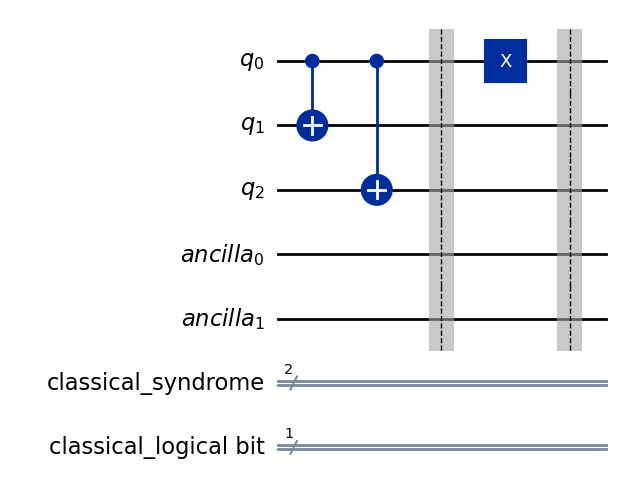

In [37]:
qc.draw('mpl')

### **Decoding the error**

In [38]:
# Syndrome measurement (parity checks)
qc.cx(qreg[1], areg[0])  # Ancilla 1 checks between 0 and 1
qc.cx(qreg[0], areg[0])
qc.cx(qreg[1], areg[1])  # Ancilla 2 checks between 1 and 2
qc.cx(qreg[2], areg[1])

# Measure syndrome bits (c0, c1)
qc.measure([areg[0], areg[1]],creg_syndrome)  # Stores result in Ancilla classical register
qc.barrier()

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=5, num_clbits=0, params=[]), qubits=(<Qubit register=(3, "q"), index=0>, <Qubit register=(3, "q"), index=1>, <Qubit register=(3, "q"), index=2>, <AncillaQubit register=(2, "ancilla"), index=0>, <AncillaQubit register=(2, "ancilla"), index=1>), clbits=())

### **Error Correction**

In [39]:
 # # Apply corrections using syndrome register as a single integer

with qc.if_test((creg_syndrome, 1)):  # If syndrome = 01 (binary) = 1 (decimal)
    qc.x(qreg[0])

with qc.if_test((creg_syndrome, 3)):  # If syndrome = 11 (binary) = 3 (decimal)
    qc.x(qreg[1])

with qc.if_test((creg_syndrome, 2)):  # If syndrome = 10 (binary) = 2 (decimal)
    qc.x(qreg[2])
qc.barrier()

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=5, num_clbits=0, params=[]), qubits=(<Qubit register=(3, "q"), index=0>, <Qubit register=(3, "q"), index=1>, <Qubit register=(3, "q"), index=2>, <AncillaQubit register=(2, "ancilla"), index=0>, <AncillaQubit register=(2, "ancilla"), index=1>), clbits=())

### **Reverse the Encoding and Measure The Logical bit**

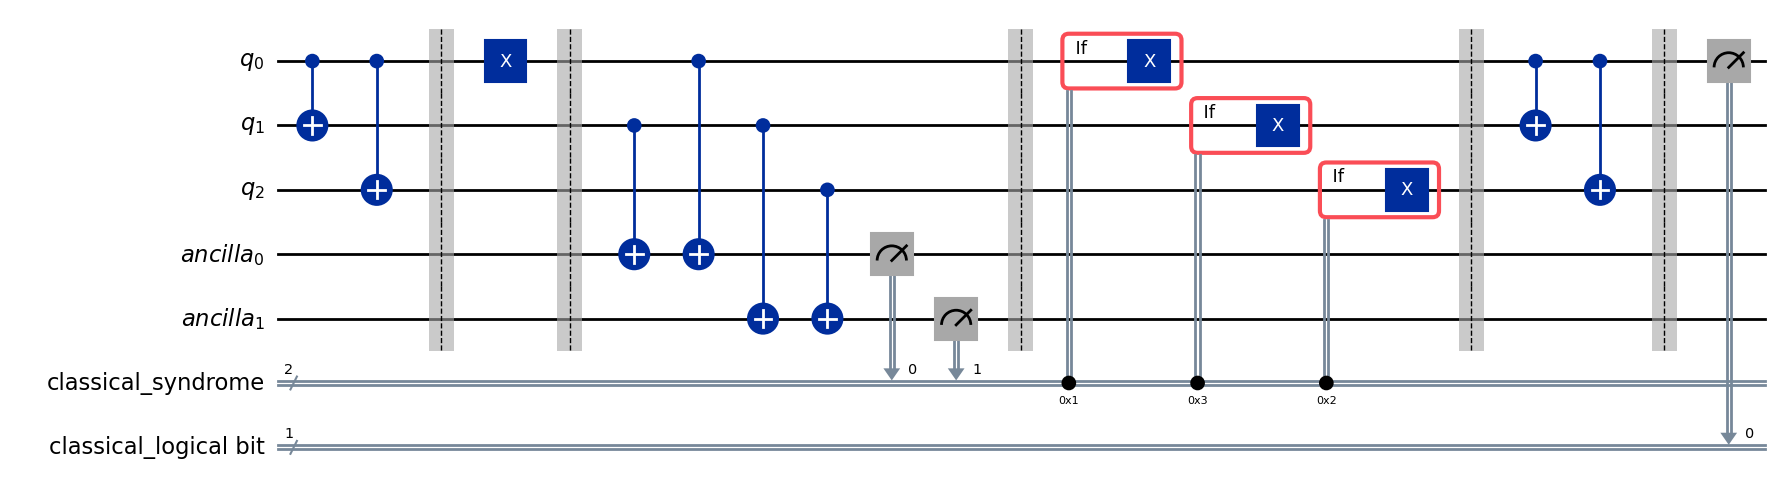

In [40]:
#decoding : reversing the encoding process (apply the same gates again)
qc.cx(qreg[0], qreg[1])
qc.cx(qreg[0], qreg[2])
qc.barrier()

# qc.measure([qreg[0],qreg[1],qreg[2]],creg_logical)

qc.measure(qreg[0],creg_logical)

qc.draw('mpl')

### **Run The Simulation**





measurement of logical bits and syndrome {'0 01': 1024}


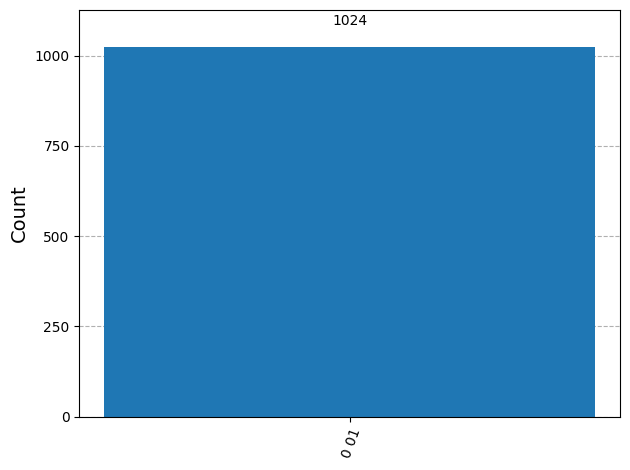

In [41]:
#Intialize the simulator
backend = AerSimulator()   #This is general purpose quantum simulator framework but qiskit does have other specialized simulators

# Run ideal simulation

job = backend.run(qc, shots=1024)

# Get results
result = job.result()
counts = result.get_counts()

#printing measurement of logical bits and syndrome

print("measurement of logical bits and syndrome",counts)
plot_histogram(counts)

### Summary

- **Encode** using entanglement for
redundancy.
- **Detect errors** with ancilla qubits via parity checks.    
- **Measure ancilla** to identify the error.
- **Correct the error** with an X gate based on the syndrome table.
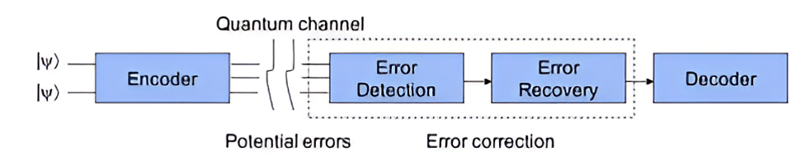

# **5. 3-Qubit Phase Flip Repitition code**

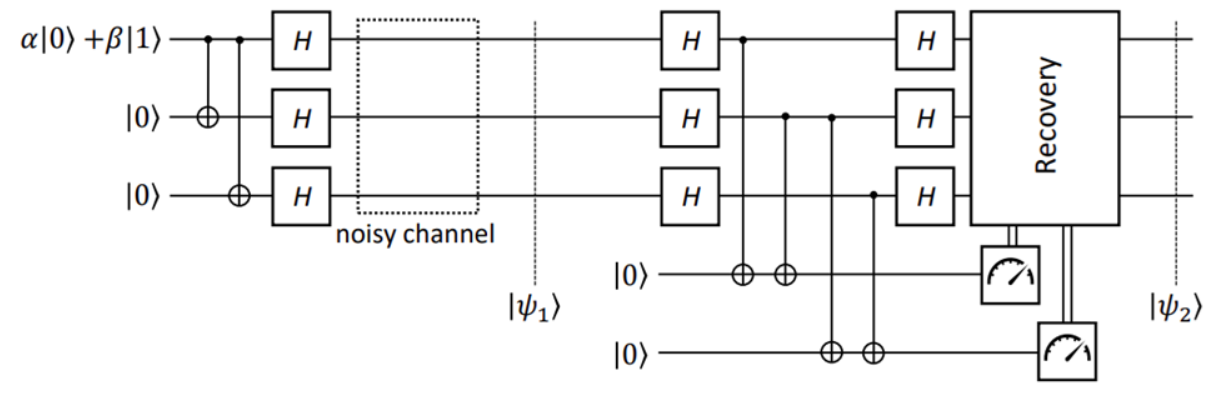

## **5.1 Encoding**

- The flow of phase flip code is similar to the bit flip but we apply hadamard to make sure the given state has a phase.
- The encoding is same as before but additionally we aaply Hadamards to make sure phases are present in the system
  
        |0⟩ → |+++⟩
        
        |1⟩ → |---⟩    
        
        α|0⟩+ β|1⟩ → α|+++⟩ + β|---⟩

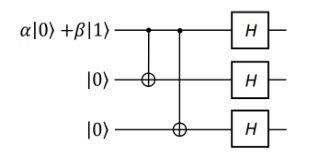

### Step 1: Initial State before encoding  
 $$(α|0⟩+ β|1⟩)⊗ |00⟩ =  α|0⟩|00⟩+ β|1⟩|11⟩$$
#### Step 2. CNOT between $q_0=|ψ⟩$ as Control bit and $q_1=∣0⟩$as target bit
  $$α|00⟩|0⟩+ β|11⟩|1⟩$$
#### Step 3. CNOT on entangled state $|q_1q_0⟩$ where $q_0$ is Control bit and $q₂=∣0⟩$ as target bit
   $$α|000⟩ + β|111⟩$$

- until here the process is same as Bit flip repitition code encoding

#### Step 4. Apply Hadamard on each qubit
- we know that for n qubit system $|000..ntimes>$
- if we apply H on every qubit on a n qubit system it will give equal superposition of all possible $2^n$ states
- Here we will have superposition of 8 states
$$
|\psi\rangle = \alpha \frac{1}{2\sqrt{2}}(|000\rangle + |001\rangle +|010\rangle +|011\rangle +|100\rangle +|101\rangle +|110\rangle + |111\rangle)
 + \beta \frac{1}{2\sqrt{2}}(|000\rangle - |001\rangle -|010\rangle +|011\rangle -|100\rangle +|101\rangle +|110\rangle - |111\rangle)
$$

### **5.2 Syndrome Measurement and Decoding**

### 5.2.1 Syndrome Measurement:
- To detect where a **phase flip error** has occurred, we need to check **phase parity** (i.e., whether the relative phase between two qubits is the same or different).
- Phase errors are turned into bit errors by applying **Hadamard (H)** gates before and after the CNOTs.
- Two **ancilla qubits** are used to measure the parity:
  - **Ancilla 1** checks the parity between qubits 0 (q₀) and 1 (q₁).
  - **Ancilla 2** checks the parity between qubits 1 (q₁) and 2 (q₂).
  - This is done using **Hadamard-CNOT-Hadamard** sequences.

- For **Ancilla 1**:
  
  1. Apply **Hadamard gates** on **q₀** and **q₁** (to convert phase errors into bit errors).
  2. Apply **CNOT** from **q₀ (control)** to **ancilla 1 (target)**.
  3. Apply **CNOT** from **q₁ (control)** to **ancilla 1 (target)**.
  4. Apply **Hadamard gates** again on **q₀** and **q₁** (to return them to the original basis).
  5. Measure **ancilla 1** to obtain the parity result.
  6. Store this measurement in classical register `creg_syndrome[0]`. (M1)

- For **Ancilla 2**:
  
  1. Apply **Hadamard gates** on **q₁** and **q₂**.
  2. Apply **CNOT** from **q₁ (control)** to **ancilla 2 (target)**.
  3. Apply **CNOT** from **q₂ (control)** to **ancilla 2 (target)**.
  4. Apply **Hadamard gates** again on **q₁** and **q₂**.
  5. Measure **ancilla 2**.
  6. Store this measurement in classical register `creg_syndrome[1]`. (M2)



### 5.2.2 Decoding
- Use the syndrome measurements to determine **which qubit** encountered a phase-flip error.
- There are 4 possible syndromes:
  - `00`: **No Error**
  - `01`: **Error on qubit 0 (q₀)**
  - `11`: **Error on qubit 1 (q₁)**
  - `10`: **Error on qubit 2 (q₂)**



### 5.3 Error Correction
- Apply a **Z gate** (phase-flip correction) to the qubit identified by the syndrome.
- After correction, measurement will yield the restored state.


## Syndrome table
\begin{array}{|c|c|c|c|c|c|c|}
\hline
\textbf{Phase Flip Error} & |\psi_1\rangle & M_1 & M_2 & \text{Syndrome} & \text{Recovery} & \text{Final State}~|\psi_f\rangle \\
\hline
\text{No Error} & \alpha |+++\rangle + \beta |---\rangle & 0 & 0 & 00 & I \otimes I \otimes I & \alpha |+++\rangle + \beta |---\rangle \\
\hline
q_0~\text{Error}~(Z_0) & \alpha |-++\rangle + \beta |+--\rangle & 1 & 0 & 10 & Z \otimes I \otimes I & \alpha |+++\rangle + \beta |---\rangle \\
\hline
q_1~\text{Error}~(Z_1) & \alpha |+-+\rangle + \beta |-+-\rangle & 1 & 1 & 11 & I \otimes Z \otimes I & \alpha |+++\rangle + \beta |---\rangle \\
\hline
q_2~\text{Error}~(Z_2) & \alpha |++-\rangle + \beta |--+\rangle & 0 & 1 & 01 & I \otimes I \otimes Z & \alpha |+++\rangle + \beta |---\rangle \\
\hline
\end{array}


## **Coding the 3-bit Phase flip code**

## **Initialize and Encode the circuit**

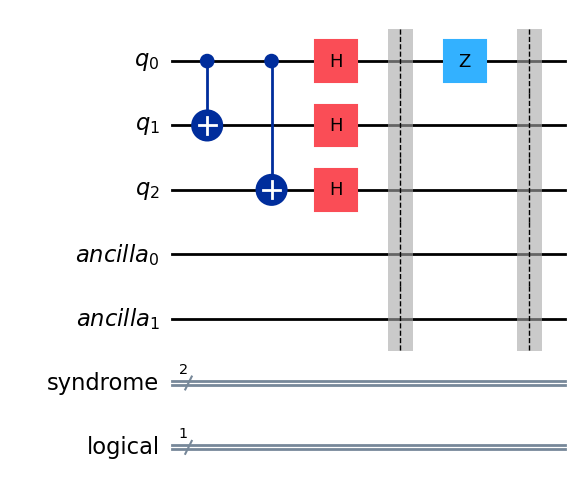

In [42]:
# Define quantum and classical registers
qreg = QuantumRegister(3, "q")  # Logical (data) qubits
areg = AncillaRegister(2, "ancilla")  # Explicitly defining ancilla qubits prevents unintended operations on ancilla qubits
creg_syndrome = ClassicalRegister(2, name="syndrome")  # Stores syndrome measurement (c0, c1)
creg_logical = ClassicalRegister(1, name="logical")  # Stores final logical qubit measurement

# Create the circuit
qc = QuantumCircuit(qreg,areg, creg_syndrome, creg_logical)

# Encoding: Spread logical qubit across 3 physical qubits ( our initial state will be entagled to two other qubits )
qc.cx(qreg[0], qreg[1])
qc.cx(qreg[0], qreg[2])
#apply Hadamards to create superpositions in all qubits
qc.h(qreg[0])
qc.h(qreg[1])
qc.h(qreg[2])
qc.barrier()

# Introduce an phase flip error on Qubit 0
qc.z(qreg[0])
qc.barrier()

qc.draw('mpl')

## **Syndrome decoding and Error correction**

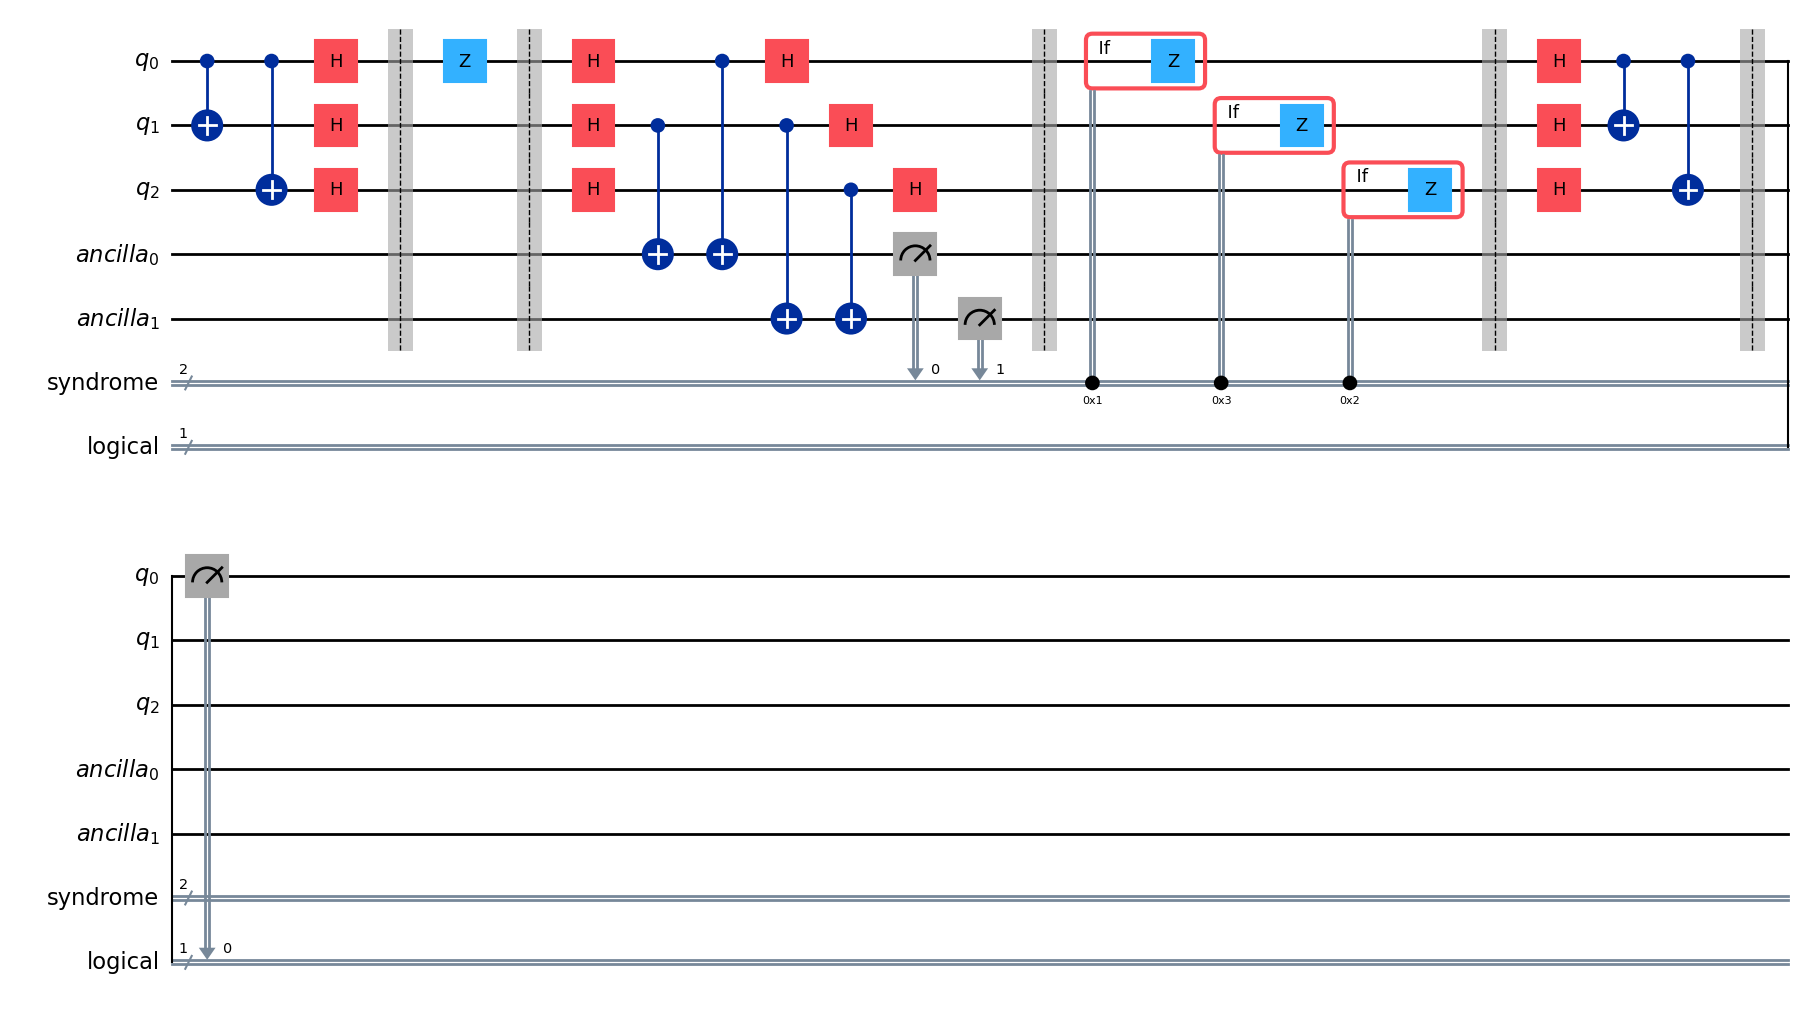

In [43]:
'''
1. After encoding we find syndromes patterns using Ancilla Bits
2. we decode those syndrome mesurements based on syndrome table
3. then flip the error prone bit
'''
# Apply Hadamard gates before syndrome detection
qc.h(qreg[0])
qc.h(qreg[1])
qc.h(qreg[2])

# Syndrome measurement (parity checks)
qc.cx(qreg[1], areg[0])  # Ancilla 1 checks between 0 and 1
qc.cx(qreg[0], areg[0])
qc.cx(qreg[1], areg[1])  # Ancilla 2 checks between 1 and 2
qc.cx(qreg[2], areg[1])

# Measure syndrome bits (c0, c1)
qc.measure([areg[0], areg[1]],creg_syndrome)  # Stores result in Ancilla classical register


# Apply Hadamard gates again to revert to original basis
qc.h(qreg[0])
qc.h(qreg[1])
qc.h(qreg[2])
qc.barrier()

# Apply corrections using syndrome register as a single integer
with qc.if_test((creg_syndrome, 1)):  # If syndrome = 01 (binary) = 1 (decimal)
    qc.z(qreg[0])

with qc.if_test((creg_syndrome, 3)):  # If syndrome = 11 (binary) = 3 (decimal)
    qc.z(qreg[1])

with qc.if_test((creg_syndrome, 2)):  # If syndrome = 10 (binary) = 2 (decimal)
    qc.z(qreg[2])

qc.barrier()

# Reversiing the Encoding Apply Hadamard gates again to revert to original basis and then apply Cnots
qc.h(qreg[0])
qc.h(qreg[1])
qc.h(qreg[2])

qc.cx(qreg[0], qreg[1])
qc.cx(qreg[0], qreg[2])
qc.barrier()

#measure the logical bit
qc.measure(qreg[0],creg_logical[0])

qc.draw('mpl')

## Run the simulation

measurement of logical bits and syndrome {'0 01': 1024}


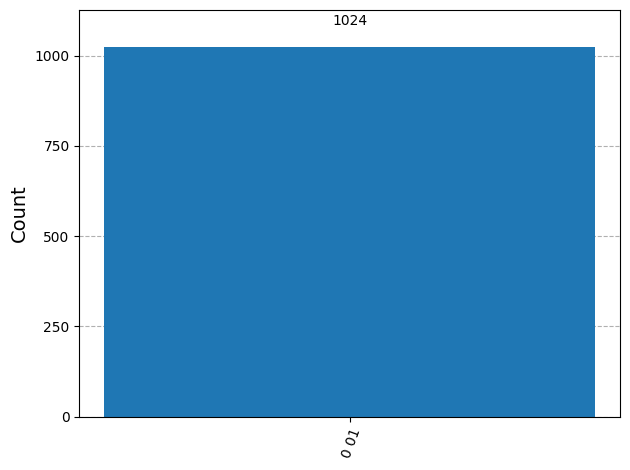

In [44]:
#Intialize the simulator
backend = AerSimulator()   #This is general purpose quantum simulator framework but qiskit does have other specialized simulators

# Run ideal simulation

job = backend.run(qc, shots=1024)

# Get results
result = job.result()
counts = result.get_counts()

#printing measurement of logical bits and syndrome

print("measurement of logical bits and syndrome",counts)
plot_histogram(counts)

# **6. Stabilizer Formalism**
Before actually coding the 9 qubit Shor Code lets take a look if we have any easier way to do syndrome decoding and measurement.

> **Is there a more systematic, elegant way?**  
> **Yes!** Stabilizer Codes — they detect errors using **symmetry and group theory**.  
> This is a generalization of **classical coding theory**.




### Let's Consider a Simple Single Qubit Error

#### Phase Error: **Z**
- $ Z|0\rangle = |0\rangle $
- $ Z|1\rangle = -|1\rangle $

#### Phase Error Z in Another Basis:
-  $Z|+\rangle = |-\rangle $
- $Z|-\rangle = |+\rangle $

This basically acts like a **bit flip** in the $( |+\rangle, |-\rangle $ basis.




Consider **3 Qubit Bit Flip Code** encoding:  
$$
\alpha|0\rangle + \beta|1\rangle \rightarrow \alpha|000\rangle + \beta|111\rangle
$$

#### If there is no error:
$$
ZZI(\alpha|000\rangle + \beta|111\rangle) = \alpha|000\rangle + \beta|111\rangle
$$
- $Z $ on $0$ → $+1$, so no sign change.  
- $ Z $ on $1$ → $-1$, but done **twice** on qubits $1 & 2$ → $(-1)^2 = +1 $

 **Stabilized**: No error detected.



### Now Consider an Error on 3rd Qubit

Our state becomes:  
$$
\alpha|001\rangle + \beta|110\rangle
$$

Apply **ZZI** (Ancilla 1):  
- $ZZI|001\rangle = +|001\rangle $  
- $ ZZI|110\rangle = +|110\rangle $   Error **not detected**.

Apply **IZZ** (Ancilla 2):  
- $IZZ|001\rangle = -|001\rangle $  
- $ IZZ|110\rangle = -|110\rangle $  
 **Error Detected**


### 6.1 What is a Stabilizer?

- These operators — **ZZI**, **IZZ** — are enough to detect **any single qubit bit-flip error** in the 3-qubit Bit Flip encoding.

#### They are called the **Stabilizers (generators)** of the 3-Qubit Bit Flip Code.





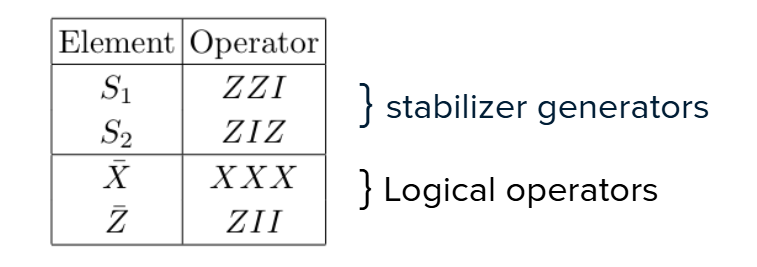

- **Stabilizer Group**:
$$
\{ III, ZZI, IZZ, ZIZ \}
$$

(All the elements in the group **commute** with each other.)

### Formal Definition of Stabilizer:

A **stabilizer** $ S $ of a quantum state $ |\psi\rangle $ is a Hermitian operator such that:  
$$
S|\psi\rangle = |\psi\rangle
$$

That is, $|\psi\rangle $ is a **+1 eigenstate** of $ S $.


# Rewrite the 3-bit Bit Flip Repitition code with stabilizers

- We Know How this code is executed without Stabilizers
- But with Stabilizers the syndrome measurements becomes a bit simpler
- Other than that every thing else states the same

#### **Circuit without Stabilizers**

 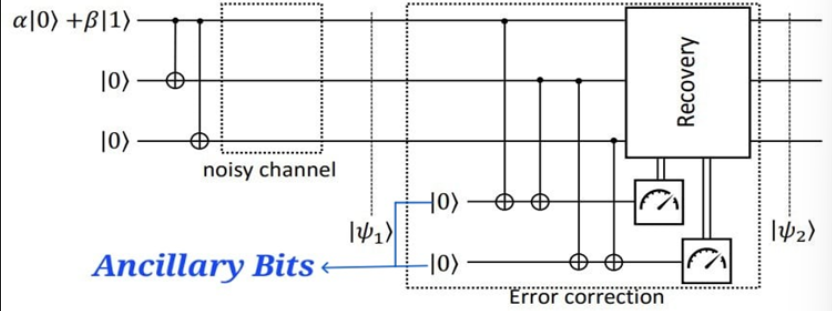


#### **Stabilizer Table**
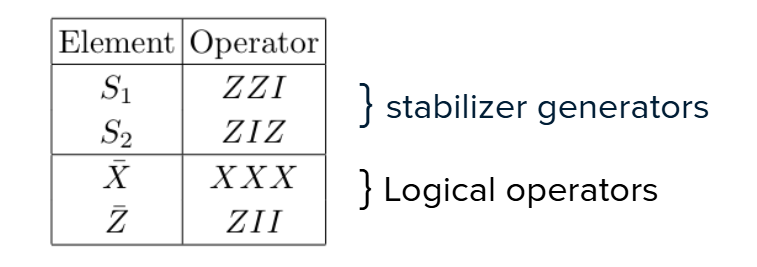

#### **Syndrome Measurement with Stabilizers Circuit**

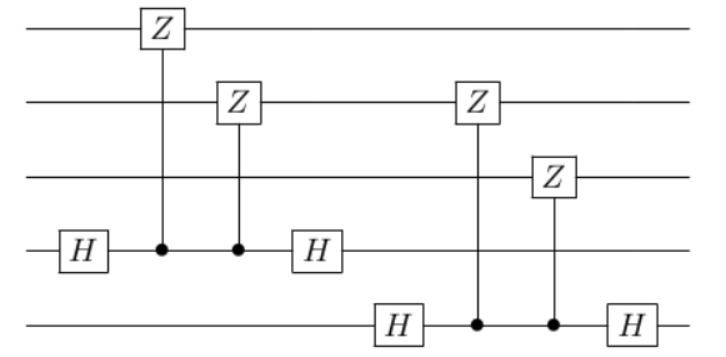

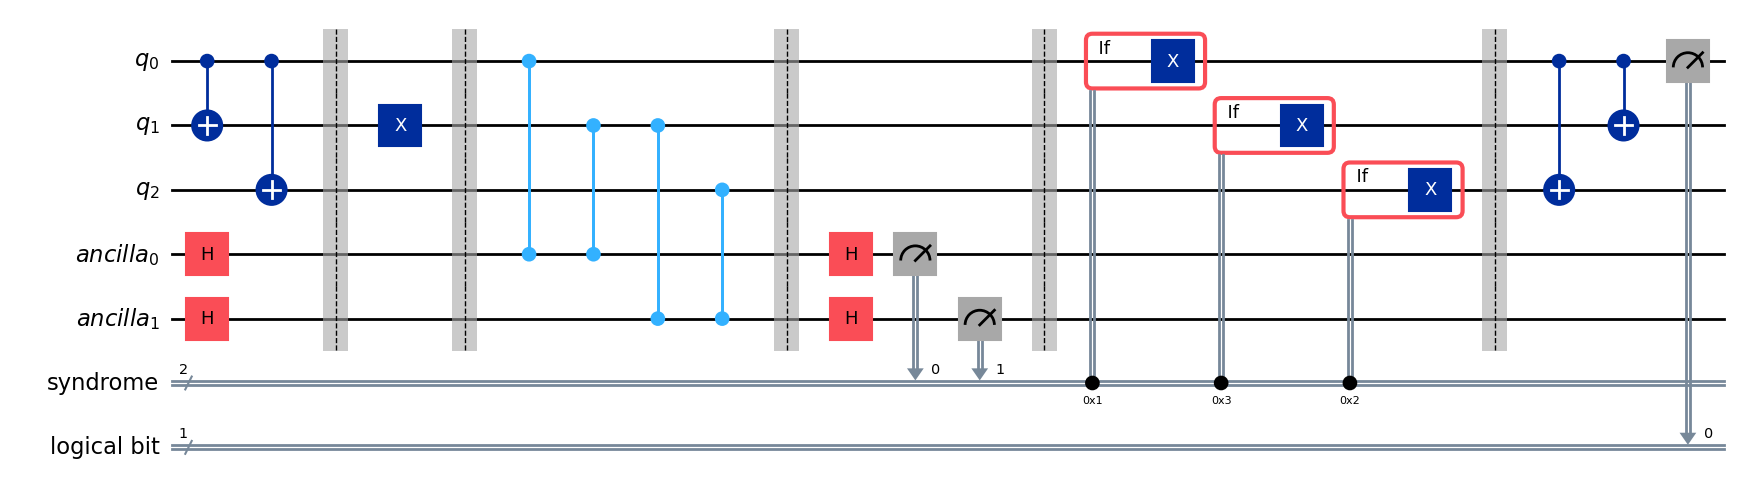

In [45]:
#import Libraries
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, AncillaRegister, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from qiskit.quantum_info import Statevector


# example code  for When initial state is |0> ,  Bit Flip error on second Qubit

# Define quantum registers ( Data qubits and Ancilla(2 for 2 Stabilizers)
qreg = QuantumRegister(3, "q")
areg = AncillaRegister(2, "ancilla")

#classical registers
creg_syndrome = ClassicalRegister(2, name="syndrome")  # Stores syndrome measurement (c0, c1)
creg_logical = ClassicalRegister(1, name="logical bit")  # Stores final logical qubit measurement

# Create the circuit
qc = QuantumCircuit(qreg,areg, creg_syndrome, creg_logical)
simulator = AerSimulator()

'''encoding'''
qc.cx(qreg[0], qreg[1])
qc.cx(qreg[0], qreg[2])


'''ancilla Initialaization'''
qc.h(areg[0])
qc.h(areg[1])

qc.barrier()


'''Induce error'''
# Introduce an phase fliperror on Qubit t
qc.x(qreg[1])
qc.barrier()


'''Syndrome Measurement'''

'''  1. Apply Stabilizers ZZI and IZZ using projective measurement
     2. For The CZ gates take Control a Ancilla and data qubits as target
     3. If there is an error these will give phase kickback to ancilla(which is already in state of |+>)
         ancilla-1    ancilla-2  Error-Qubit
            |+>        |+>        No error
            |->        |+>        1 (q0)
            |->        |->        2 (q1)
            |+>        |->        3 (q2)

     4. But Before Measuring the ancilla apply Hadamard to change the basis
         So H|+> = |0>
            H|-> = |1>
       Our syndrome table will look like this
            ancilla-1    ancilla-2  Error-Qubit
                0           0        No error
                1           0        1 (q0)
                1           1        2 (q1)
                1           1        3 (q2)
       This is same table as we get when we do without stablilizers
'''

#Apply Stabilizer ZZI with control as ancilla 1
qc.cz(areg[0],qreg[0])
qc.cz(areg[0],qreg[1])

#Apply Stabilizer IZZ with control as ancilla 2
qc.cz(areg[1],qreg[1])
qc.cz(areg[1],qreg[2])

qc.barrier()


# Apply Hadamard to Ancilla
qc.h(areg[0])
qc.h(areg[1])

# Measure The Ancilla To Get Syndrome
qc.measure([areg[0], areg[1]],creg_syndrome)  # Stores result in Ancilla classical register
qc.barrier()


'''Correction Based On syndrome'''
#Apply corrections using syndrome register as a single integer
    # qc.x(qreg[0]).c_if(creg_syndrome, 1)  # If syndrome = 01 (decimal 1), flip Qubit 0
    # qc.x(qreg[1]).c_if(creg_syndrome, 3)  # If syndrome = 11 (decimal 3), flip Qubit 1
    # qc.x(qreg[2]).c_if(creg_syndrome, 2)  # If syndrome = 10 (decimal 2), flip Qubit 2

with qc.if_test((creg_syndrome, 1)):  # If syndrome = 01 (binary) = 1 (decimal)
   qc.x(qreg[0])

with qc.if_test((creg_syndrome, 3)):  # If syndrome = 11 (binary) = 3 (decimal)
    qc.x(qreg[1])

with qc.if_test((creg_syndrome, 2)):  # If syndrome = 10 (binary) = 2 (decimal)
    qc.x(qreg[2])

qc.barrier()


'''Reversing The encoding '''
qc.cx(qreg[0], qreg[2])
qc.cx(qreg[0], qreg[1])

#measure
qc.measure(qreg[0],creg_logical)

qc.draw('mpl')



measurement of logical bits and syndrome {'0 11': 1024}


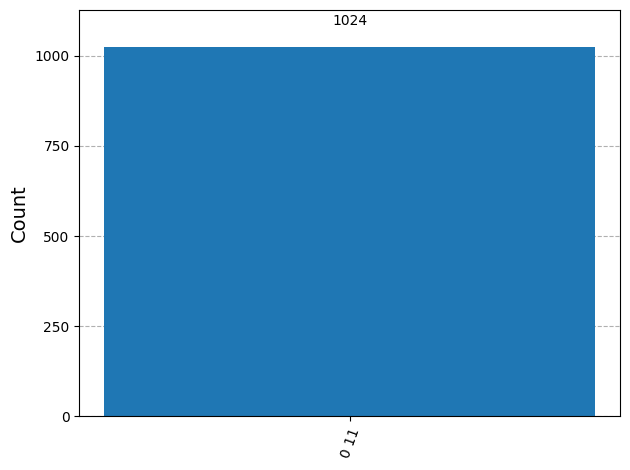

In [46]:
#Intialize the simulator
backend = AerSimulator()   #This is general purpose quantum simulator framework but qiskit does have other specialized simulators

# Run ideal simulation

job = backend.run(qc, shots=1024)

# Get results
result = job.result()
counts = result.get_counts()

#printing measurement of logical bits and syndrome

print("measurement of logical bits and syndrome",counts)
plot_histogram(counts)

# Rewriting the 3-Qubit Phase Flip code with Stabilizers

- Similar to How we executed the Bit flip code we can ecspect the same
- Only the syndrome measurement part Changes.
- But the important thing in normal syndrome measuremet we apply hadamards before after the syndrome calculation
- With Stabilizer we can skip that part and claculate the syndromes directly

## circuit without Stabilizers

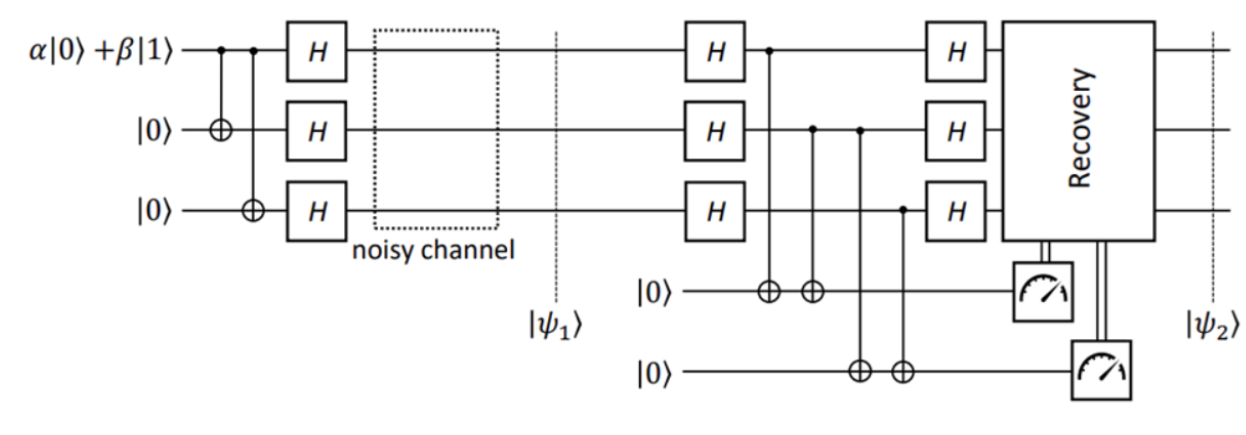

# Stabilizer of 3 qubit phase flip code
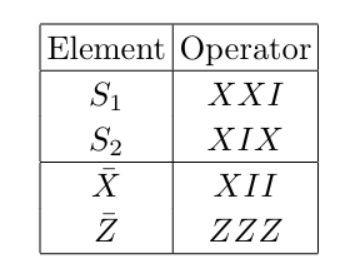

## Syndrome measurement using stabilizers

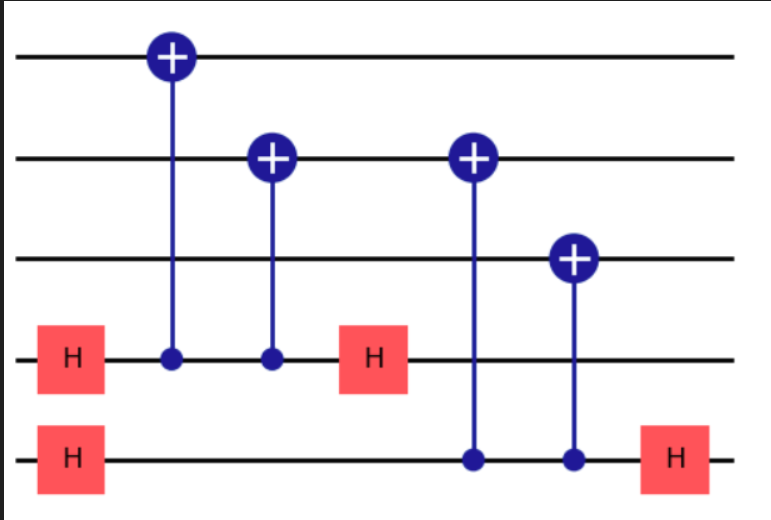

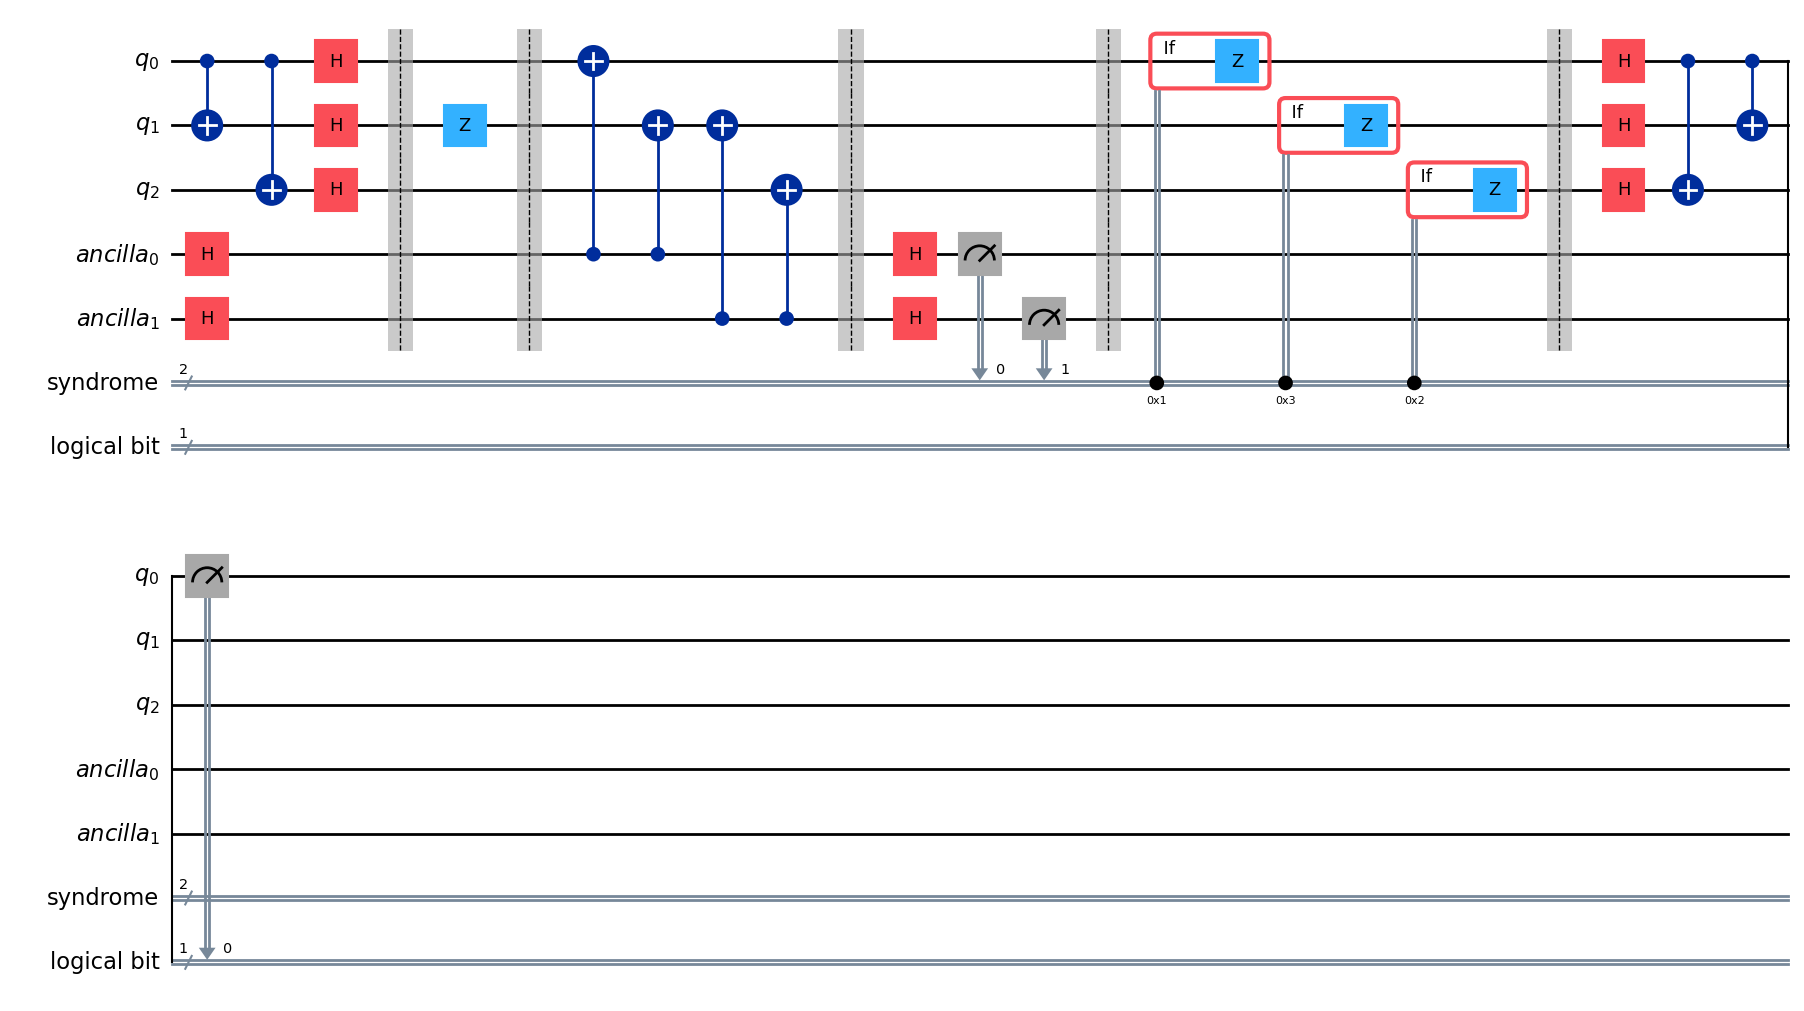

In [47]:
#import Libraries
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, AncillaRegister, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from qiskit.quantum_info import Statevector


# example code  for When initial state is |0> ,  Phase Flip error on second Qubit

# Define quantum registers ( Data qubits and Ancilla(2 for 2 Stabilizers)
qreg = QuantumRegister(3, "q")
areg = AncillaRegister(2, "ancilla")

#classical registers
creg_syndrome = ClassicalRegister(2, name="syndrome")  # Stores syndrome measurement (c0, c1)
creg_logical = ClassicalRegister(1, name="logical bit")  # Stores final logical qubit measurement

# Create the circuit
qc = QuantumCircuit(qreg,areg, creg_syndrome, creg_logical)
simulator = AerSimulator()

'''encoding'''
qc.cx(qreg[0], qreg[1])
qc.cx(qreg[0], qreg[2])
#apply Hadamards to create superpositions in all qubits
qc.h(qreg[0])
qc.h(qreg[1])
qc.h(qreg[2])



'''ancilla Initialaization'''
qc.h(areg[0])
qc.h(areg[1])

qc.barrier()


'''Induce error'''
qc.z(qreg[1])
qc.barrier()


'''Syndrome Measurement'''

'''  1. Apply Stabilizers XXI and IXX using projective measurement
     2. For The CX gates take Control a Ancilla and data qubits as target
     3. If there is an error these will give phase kickback to ancilla(which is already in state of |+>)
         ancilla-1    ancilla-2  Error-Qubit
            |+>        |+>        No error
            |->        |+>        1 (q0)
            |->        |->        2 (q1)
            |+>        |->        3 (q2)

     4. But Before Measuring the ancilla apply Hadamard to change the basis
         So H|+> = |0>
            H|-> = |1>
       Our syndrome table will look like this
            ancilla-1    ancilla-2  Phase Error-Qubit
                0           0        No error
                1           0        1 (q0)
                1           1        2 (q1)
                1           1        3 (q2)
       This is same table as we get when we do without stablilizers
'''

#Apply Stabilizer XXI with control as ancilla 1
qc.cx(areg[0],qreg[0])
qc.cx(areg[0],qreg[1])

#Apply Stabilizer IXX with control as ancilla 2
qc.cx(areg[1],qreg[1])
qc.cx(areg[1],qreg[2])

qc.barrier()

# Apply Hadamard to Ancilla to change th basis
qc.h(areg[0])
qc.h(areg[1])

# Measure The Ancilla To Get Syndrome
qc.measure([areg[0], areg[1]],creg_syndrome)  # Stores result in Ancilla classical register
qc.barrier()


'''Correction Based On syndrome'''
#Apply corrections using syndrome register as a single integer
    # qc.x(qreg[0]).c_if(creg_syndrome, 1)  # If syndrome = 01 (decimal 1), flip Qubit 0
    # qc.x(qreg[1]).c_if(creg_syndrome, 3)  # If syndrome = 11 (decimal 3), flip Qubit 1
    # qc.x(qreg[2]).c_if(creg_syndrome, 2)  # If syndrome = 10 (decimal 2), flip Qubit 2

with qc.if_test((creg_syndrome, 1)):  # If syndrome = 01 (binary) = 1 (decimal)
   qc.z(qreg[0])

with qc.if_test((creg_syndrome, 3)):  # If syndrome = 11 (binary) = 3 (decimal)
    qc.z(qreg[1])

with qc.if_test((creg_syndrome, 2)):  # If syndrome = 10 (binary) = 2 (decimal)
    qc.z(qreg[2])

qc.barrier()


'''Reversing The encoding '''
qc.h(qreg[2])
qc.h(qreg[1])
qc.h(qreg[0])
qc.cx(qreg[0], qreg[2])
qc.cx(qreg[0], qreg[1])

#measure
qc.measure(qreg[0],creg_logical)

qc.draw('mpl')


measurement of logical bits and syndrome {'0 11': 1024}


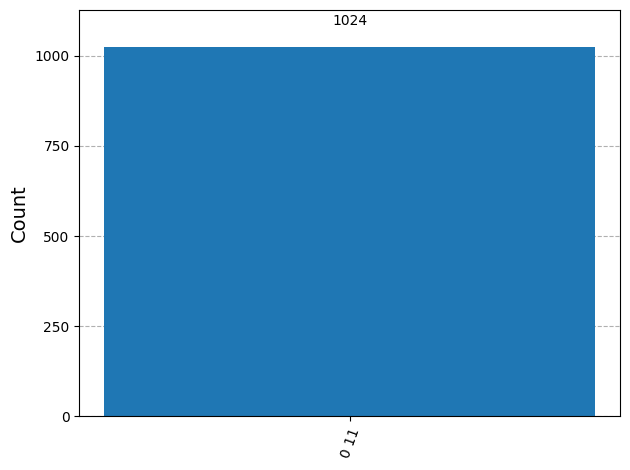

In [48]:
#Intialize the simulator
backend = AerSimulator()   #This is general purpose quantum simulator framework but qiskit does have other specialized simulators

# Run ideal simulation

job = backend.run(qc, shots=1024)

# Get results
result = job.result()
counts = result.get_counts()

#printing measurement of logical bits and syndrome

print("measurement of logical bits and syndrome",counts)
plot_histogram(counts)

# **9-Qubit Shor code**
It is the first General Purpose Code That Can Detect both Single qubit Phase and Bit Flip errors

# 9-Qubit Shor Code: General-Purpose Quantum Error Correction

The 9-qubit Shor code is the first general-purpose quantum error correction code capable of detecting and correcting both bit-flip (X) and phase-flip (Z) errors.

## Encoding

A single logical qubit is encoded into 9 physical qubits by concatenating:
- A 3-qubit bit-flip code, and
- A 3-qubit phase-flip code

This creates 3 blocks of 3 qubits each:
- First, a phase-flip code encodes the logical qubit into 3 qubits.
- Then, each of those 3 qubits is encoded with a bit-flip code.

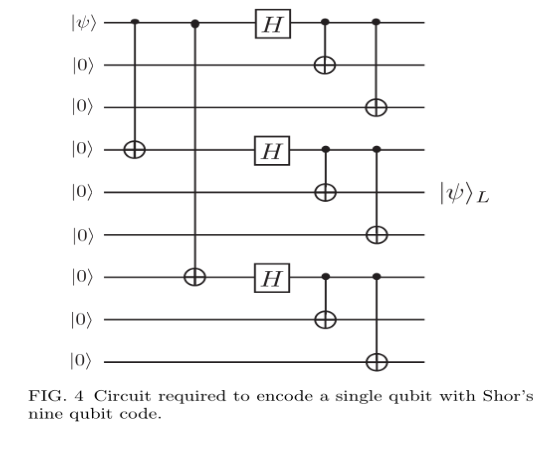

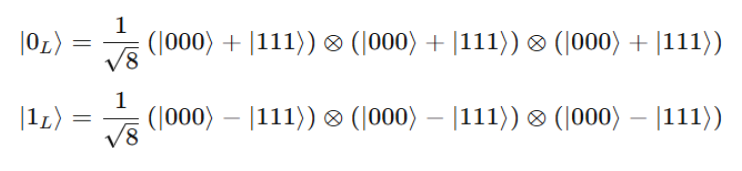

## Error Detection

- Majority voting is used independently in each layer:
  - For bit-flip errors: Voting is done across each 3-qubit block.
  - For phase-flip errors: Voting is done across the 3 blocks as a whole (via basis change).

## Error Correction

- Bit-flip errors are corrected using X gates.
- Phase-flip errors are corrected using Z gates.
- After correction, decoding restores the logical qubit.

## Summary

| Feature           | Description                                                  |
|------------------|--------------------------------------------------------------|
| Code Name        | 9-Qubit Shor Code                                            |
| Errors Detected  | Bit-flip (X) and Phase-flip (Z)                              |
| Encoding Method  | Concatenation of 3-qubit bit-flip and 3-qubit phase-flip     |
| Correction Gates | X for bit-flips, Z for phase-flips                           |


## **Stabilizer Table**


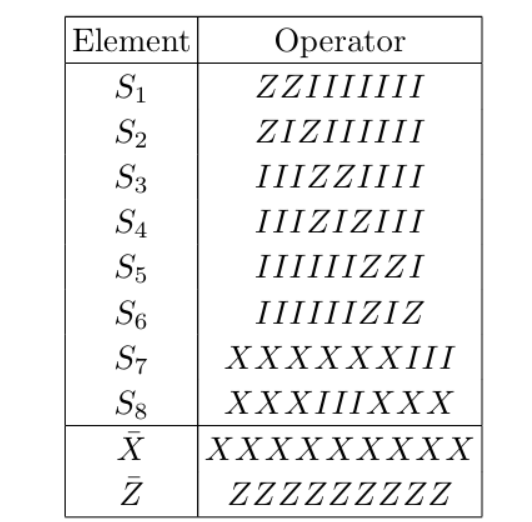

## Initialization and Encoding

In [49]:
#import Libraries
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, AncillaRegister, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from qiskit.quantum_info import Statevector


# Quantum Registers
qreg = QuantumRegister(9, "q")                # 9 data qubits
areg = QuantumRegister(8, "ancilla")       # 8 ancilla: For 8 stabilizers

#classical Registers
creg_syndrome_x = ClassicalRegister(6, "synd_inner")  # Inner layer syndromes # 6 X stabilizers detects x errors
creg_syndrome_z = ClassicalRegister(2, "synd_outer")  # Outer layer syndromes # 2 Z stabilizers detects z errors
creg_logical = ClassicalRegister(1, "logical")            # Logical output
qc = QuantumCircuit(qreg, areg, creg_syndrome_x, creg_syndrome_z, creg_logical)
simulator = AerSimulator()

''' Encoding'''
# Outer layer (phase-flip protection in normal basis → bit-flip in Hadamard)
qc.cx(qreg[0], qreg[3])
qc.cx(qreg[0], qreg[6])
qc.h(qreg[0])
qc.h(qreg[3])
qc.h(qreg[6])

# Inner layer (bit-flip protection in Hadamard basis → phase-flip in normal)
qc.cx(qreg[0], qreg[1])
qc.cx(qreg[0], qreg[2])
qc.cx(qreg[3], qreg[4])
qc.cx(qreg[3], qreg[5])
qc.cx(qreg[6], qreg[7])
qc.cx(qreg[6], qreg[8])

'''Ancilla initialization'''
qc.h(areg[0])
qc.h(areg[1])
qc.h(areg[2])
qc.h(areg[3])
qc.h(areg[4])
qc.h(areg[5])
qc.h(areg[6])
qc.h(areg[7])

qc.barrier()

'''Introduce error'''
# qc.x(qreg[t])  # Bit-flip error in Hadamard basis
qc.z(qreg[0])  # Phase-flip error in Hadamard basis (uncomment to test)

qc.barrier()




CircuitInstruction(operation=Instruction(name='barrier', num_qubits=17, num_clbits=0, params=[]), qubits=(<Qubit register=(9, "q"), index=0>, <Qubit register=(9, "q"), index=1>, <Qubit register=(9, "q"), index=2>, <Qubit register=(9, "q"), index=3>, <Qubit register=(9, "q"), index=4>, <Qubit register=(9, "q"), index=5>, <Qubit register=(9, "q"), index=6>, <Qubit register=(9, "q"), index=7>, <Qubit register=(9, "q"), index=8>, <Qubit register=(8, "ancilla"), index=0>, <Qubit register=(8, "ancilla"), index=1>, <Qubit register=(8, "ancilla"), index=2>, <Qubit register=(8, "ancilla"), index=3>, <Qubit register=(8, "ancilla"), index=4>, <Qubit register=(8, "ancilla"), index=5>, <Qubit register=(8, "ancilla"), index=6>, <Qubit register=(8, "ancilla"), index=7>), clbits=())

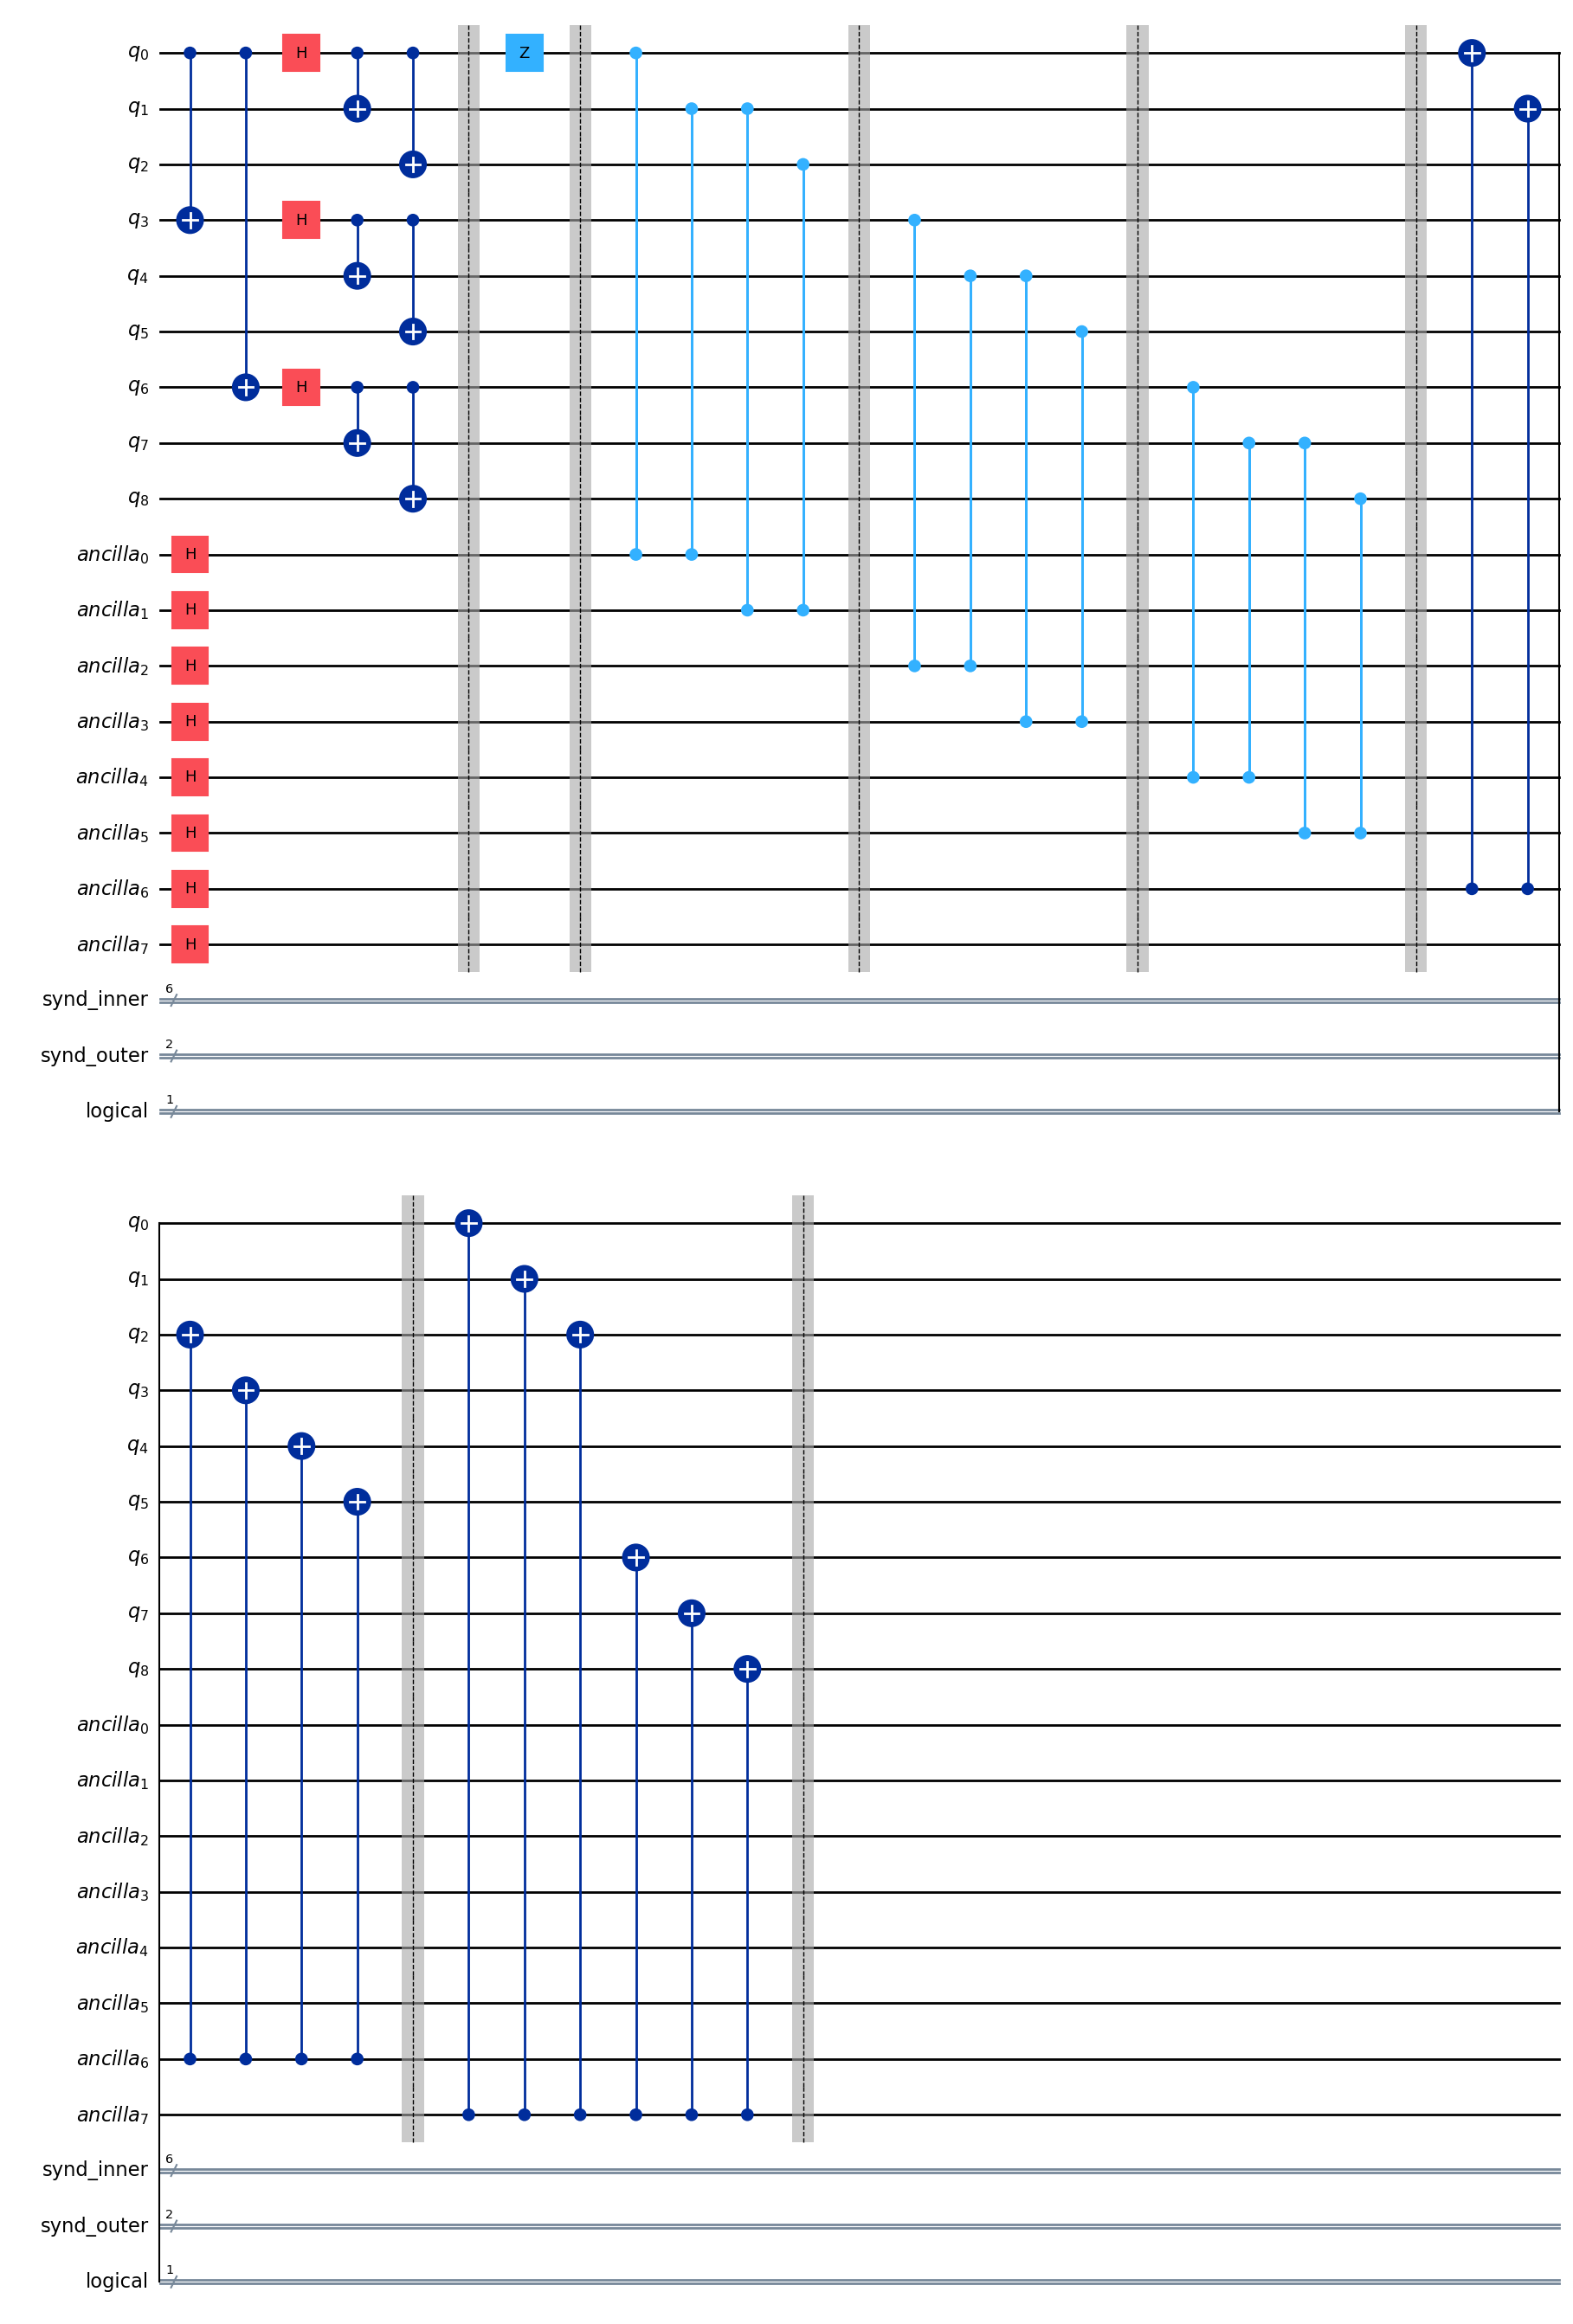

In [50]:
'''Syndrome Measurement'''

''' Inner Layer: Detect X errors (original Z errors)'''
''' Z stabilizers'''

'''block 1 Comprises of stabilizer 1 and stabilzier 2 AND  Qubits (0,1,2)'''
# stabilizer 1  ZZIIIIIII
qc.cz(areg[0],qreg[0])
qc.cz(areg[0],qreg[1])

#Stabilizer 2 IZZIIIIII
qc.cz(areg[1],qreg[1])
qc.cz(areg[1],qreg[2])

qc.barrier()

'''block 2 Comprises of stabilizer 3 and stabilzier 4 AND  Qubits (3,4,5)'''
# stabilizer 3  IIIZZIIII
qc.cz(areg[2],qreg[3])
qc.cz(areg[2],qreg[4])

#Stabilizer 4 IIIIZZIII
qc.cz(areg[3],qreg[4])
qc.cz(areg[3],qreg[5])

qc.barrier()

'''block 3 Comprises of stabilizer 5 and stabilzier 6 AND  Qubits (6,7,8)'''
# stabilizer 5  IIIIIIZZI
qc.cz(areg[4],qreg[6])
qc.cz(areg[4],qreg[7])

#Stabilizer 6 IIIIIIIZZ
qc.cz(areg[5],qreg[7])
qc.cz(areg[5],qreg[8])


qc.barrier()

'''Outer Layer: Detect Z errors Using X stabilizers'''
''' Block Consists of 0,3,6'''
#stabilizer 7 XXXXXXIII
qc.cx(areg[6],qreg[0])
qc.cx(areg[6],qreg[1])
qc.cx(areg[6],qreg[2])
qc.cx(areg[6],qreg[3])
qc.cx(areg[6],qreg[4])
qc.cx(areg[6],qreg[5])

qc.barrier()

#stabilizer 8 XXXIIIXXX
qc.cx(areg[7],qreg[0])
qc.cx(areg[7],qreg[1])
qc.cx(areg[7],qreg[2])
qc.cx(areg[7],qreg[6])
qc.cx(areg[7],qreg[7])
qc.cx(areg[7],qreg[8])

qc.barrier()

qc.draw('mpl')


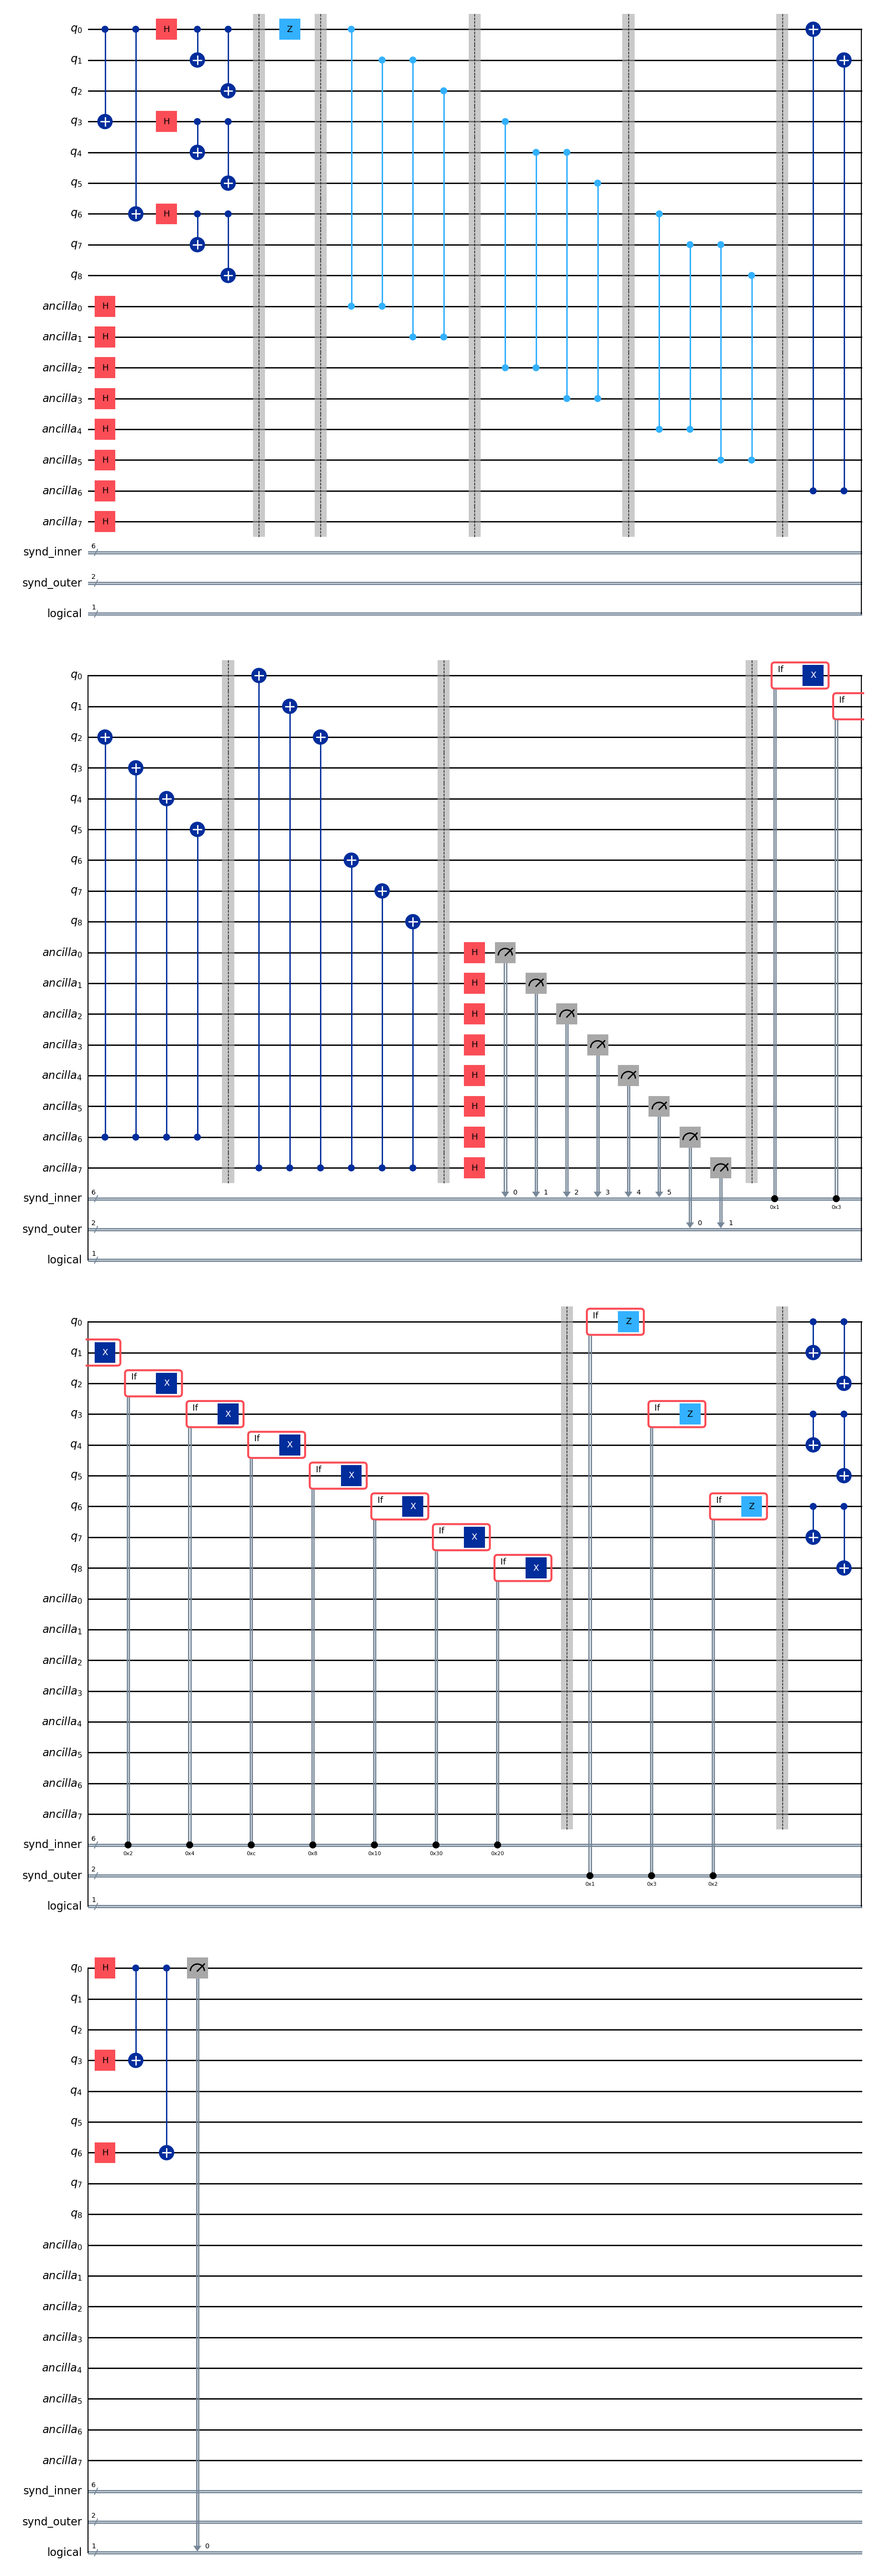

In [51]:
'''Measure Ancilla's'''
#Measure Ancilla's

# change the ancilla basis before measuring
qc.h(areg[0])
qc.h(areg[1])
qc.h(areg[2])
qc.h(areg[3])
qc.h(areg[4])
qc.h(areg[5])
qc.h(areg[6])
qc.h(areg[7])

# Block 1: measure the syndrome
qc.measure([areg[0],areg[1]],[creg_syndrome_x[0],creg_syndrome_x[1]])

#block 2 measure the syndrome
qc.measure([areg[2],areg[3]],[creg_syndrome_x[2],creg_syndrome_x[3]])

#block 3 measure the syndrome
qc.measure([areg[4],areg[5]],[creg_syndrome_x[4],creg_syndrome_x[5]])

# Outer Block

# measure
qc.measure([areg[6],areg[7]], [creg_syndrome_z[0], creg_syndrome_z[1]])

qc.barrier()

''' Correction Based On Z stabilizers for each block'''

'''block 1 [0,1,2]'''
# Block 1 (First two  Ancillabits)
with qc.if_test((creg_syndrome_x, 1)):  # If syndrome = 01 (binary) = 1 (decimal)
   qc.x(qreg[0])

with qc.if_test((creg_syndrome_x, 3)):  # If syndrome = 11 (binary) = 3 (decimal)
    qc.x(qreg[1])

with qc.if_test((creg_syndrome_x, 2)):  # If syndrome = 10 (binary) = 2 (decimal)
    qc.x(qreg[2])


'''block 2 [3,4,5] and 2,3 ancillas'''
with qc.if_test((creg_syndrome_x, 1 << 2)):  # 01 << 2 ->  000100 -> Flip q[3]
   qc.x(qreg[3])

with qc.if_test((creg_syndrome_x, 3 << 2)):  # 11 << 2 ->  001100 -> Flip q[4]
    qc.x(qreg[4])

with qc.if_test((creg_syndrome_x,2 << 2)):  # 10 << 2 ->  001000 -> Flip q[5]
    qc.x(qreg[5])



'''block 3 [6,7,8] and 4,5 ancillas'''
with qc.if_test((creg_syndrome_x, 1 << 4)):  # 01 << 4 -> 010000 -> Flip q[6]
   qc.x(qreg[6])

with qc.if_test((creg_syndrome_x, 3 <<  4)):  # 11 << 4 -> 11000 -> Flip q[7]
    qc.x(qreg[7])

with qc.if_test((creg_syndrome_x,2 << 4)):  # 10 << 4 -> 100000 -> Flip q[8]
    qc.x(qreg[8])

qc.barrier()


'''Corection Based on Z stabilizers on the block [0,3,6]'''
with qc.if_test((creg_syndrome_z, 1)):  # 01: Flip q[0]
   qc.z(qreg[0])

with qc.if_test((creg_syndrome_z, 3)):  # 11: Flip q[3]
    qc.z(qreg[3])

with qc.if_test((creg_syndrome_z, 2)): # 10: Flip q[6]
    qc.z(qreg[6])

qc.barrier()


'''Decode Inner Layer encoding'''
qc.cx(qreg[0], qreg[1])
qc.cx(qreg[0], qreg[2])
qc.cx(qreg[3], qreg[4])
qc.cx(qreg[3], qreg[5])
qc.cx(qreg[6], qreg[7])
qc.cx(qreg[6], qreg[8])

# Return to normal basis
qc.h(qreg[0])
qc.h(qreg[3])
qc.h(qreg[6])

''' Decode Outer Layer'''
qc.cx(qreg[0], qreg[3])
qc.cx(qreg[0], qreg[6])

qc.measure(qreg[0], creg_logical)

qc.draw('mpl')

measurement of logical bits and syndrome {'1 11 000000': 1024}


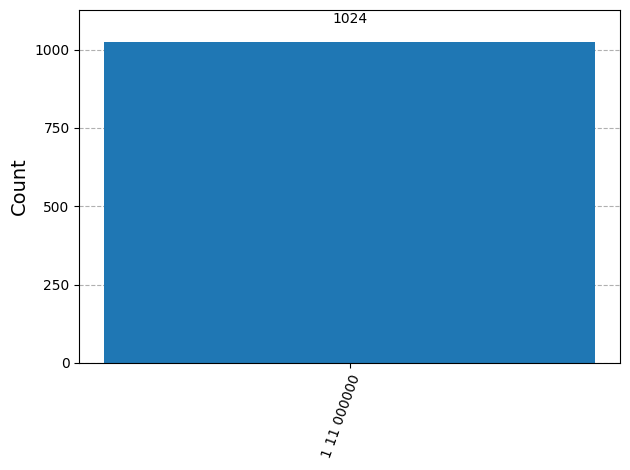

In [52]:
#Intialize the simulator
backend = AerSimulator()   #This is general purpose quantum simulator framework but qiskit does have other specialized simulators

# Run ideal simulation

job = backend.run(qc, shots=1024)

# Get results
result = job.result()
counts = result.get_counts()

#printing measurement of logical bits and syndrome

print("measurement of logical bits and syndrome",counts)
plot_histogram(counts)